# Ugail–Howard Consciousness Dynamics — Experiments & Empirical Validation
## Monte Carlo, ablation, sensitivity, Sleep-EDF validation

**Authors:** Hassan Ugail & Newton Howard

Cite: H. Ugail and N. Howard, “Quantifying the dynamics of consciousness using
hierarchical integration, organised complexity and metastability,” arXiv preprint
arXiv:2512.10972, Dec. 2025.



---

This notebook is the **full experimental pipeline** for the Ugail–Howard
framework. It is self-contained (no external library beyond pip packages)
and reproduces every result reported in the manuscript's main text and
appendix:

### Contents
1. **Section A — Simulated Monte Carlo (30 runs/state, 9 states).**
   - Per-state distributions of $\Psi$.
   - Kruskal–Wallis omnibus + pairwise Mann–Whitney adjacent-state tests.
   - ROC / AUC for conscious vs non-conscious separation (with bootstrap CIs).
   - $\Psi$ vs single-component baselines (H_eff, D, M alone) and simple
     baselines (LZC, spectral slope) — component-necessity check.
   - Pairwise adjacent-state AUC matrix (Fig 6 in the manuscript).

2. **Section B — Ablation study.**
   - Baseline (wake), No PAC, No Metastability, No Fractal.
   - Each condition ablates exactly one component of $\Psi$.

3. **Section C — Hyperparameter sensitivity.**
   - Three-panel sweep: $H_{\mathrm{opt}}$, $w_H$, $\lambda$.
   - Metric: mean and minimum adjacent-pair AUC (orientation-corrected).

4. **Section D — Within-state Monte Carlo convergence.**
   - How quickly each state's running mean converges to its long-run value.

5. **Section E — Publication figures (1–6) for the synthetic pipeline.**

6. **Section F — Sleep-EDF empirical validation (real EEG).**
   - Downloads / reads the Sleep-EDF Cassette dataset via MNE-Python.
   - Wake / N2 / REM extraction, per-subject H_opt calibration.
   - Subject-level Friedman omnibus + Wilcoxon post-hoc (Bonferroni-corrected).
   - Benchmarking $\Psi$ against LZC, spectral slope, and alpha power.
   - Publication Figures 7 (subject-level $\Psi$) and 8 (AUC heatmap).



### Runtime notes
- Sections A–E are pure CPU and take ~3–8 minutes on a modest laptop.
- Section F downloads ~100 MB the first time it is run (Sleep-EDF Cassette
  EDF files via MNE). If `DATA_DIR` below already contains the files, the
  download is skipped. Set `N_SUBJ` lower for a quick sanity-check run.

  Sleep-EDF data sample used is available at:
  https://drive.google.com/drive/folders/1zRKqwlYfLGn6OTwL4cj6ceRMvfvWjiUY?usp=sharing


In [12]:
# Install dependencies — required on a fresh Colab / local kernel.
# Safe to re-run; pip will no-op packages that are already installed.
# MNE is required to read the Sleep-EDF EDF files (Section E).
!pip install -q numpy scipy matplotlib pandas networkx scikit-learn mne
print("Dependencies installed.")


Dependencies installed.


In [13]:
# ── Imports & global configuration ─────────────────────────────────────────
import os, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy.signal import butter, filtfilt, hilbert, welch
from scipy.stats import kruskal, mannwhitneyu, wilcoxon, friedmanchisquare, rankdata
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore", category=RuntimeWarning)

np.random.seed(42)

CFG = {
    "fs":      250,
    "H_opt":   0.35,
    "sigma_H": 0.12,
    "w_H":     0.40,
    "w_D":     0.35,
    "w_M":     0.25,
    "lam":     1.0,
    "GAMMA_HIGH_SYN":  80,
    "GAMMA_HIGH_REAL": 45,
}

# Publication rcParams
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.18,
    "grid.linewidth":    0.5,
    "legend.fontsize":   9,
    "legend.frameon":    False,
    "figure.dpi":        150,
})

# Global composite weights (used by every downstream cell)
w_H, w_D, w_M, lam = CFG["w_H"], CFG["w_D"], CFG["w_M"], CFG["lam"]
H_opt = CFG["H_opt"]

print(f"Imports loaded. NumPy {np.__version__}.")
print(f"Weights: w_H={w_H}, w_D={w_D}, w_M={w_M}, lam={lam}")
print(f"H_opt = {H_opt}  (synthetic-domain prior)")


Imports loaded. NumPy 2.0.2.
Weights: w_H=0.4, w_D=0.35, w_M=0.25, lam=1.0
H_opt = 0.35  (synthetic-domain prior)


In [14]:
# ── Basic signal utilities ─────────────────────────────────────────────────

def bandpass_filter(data, fs, low, high, order=4):
    """Zero-phase Butterworth bandpass filter along the last axis."""
    nyq = fs / 2.0
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, data, axis=-1)


def generate_pink_noise(n_channels, n_samples):
    """Approximate 1/f pink noise by cumulative-summed white noise."""
    white = np.random.randn(n_channels, n_samples)
    pink = np.cumsum(white, axis=-1)
    pink -= pink.mean(axis=-1, keepdims=True)
    pink /= pink.std(axis=-1, keepdims=True) + 1e-9
    return pink


def format_label(key: str) -> str:
    """Convert internal identifiers like 'no_pac' -> 'No PAC'."""
    words = key.replace("_", " ").split()
    return " ".join(w if w.isupper() else w.capitalize() for w in words)


print("Signal utilities loaded.")


Signal utilities loaded.


In [15]:
# ── Core metrics: DFA, Lempel-Ziv, Tort MI ─────────────────────────────────
# Returns DFA scaling exponent alpha (not Hurst). For cumulative-sum signals:
#   alpha in (0.5, 1) = persistent, alpha > 1 = non-stationary fBm-like.

def dfa_hurst(x, min_win=16, max_win=None, n_win=10):
    """DFA scaling exponent alpha of a 1-D signal."""
    x = np.asarray(x)
    N = x.size
    if max_win is None:
        max_win = N // 4
    y = np.cumsum(x - x.mean())
    s_vals = np.unique(
        np.logspace(np.log10(min_win), np.log10(max_win), n_win, dtype=int)
    )
    F = []
    for s in s_vals:
        if s < 4:
            continue
        n_seg = N // s
        if n_seg < 2:
            continue
        rms = []
        for i in range(n_seg):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            p = np.polyfit(t, seg, 1)
            rms.append(np.sqrt(np.mean((seg - np.polyval(p, t)) ** 2)))
        if rms:
            F.append(np.mean(rms))
    F = np.array(F)
    if len(F) < 2:
        return 0.5
    s_use = s_vals[: len(F)]
    return float(np.polyfit(np.log(s_use), np.log(F), 1)[0])


def lempel_ziv_complexity(binary_seq):
    """Normalised LZ76 complexity of a binary sequence."""
    s = "".join(str(int(b)) for b in binary_seq)
    i, c, l = 0, 1, 1
    n = len(s)
    while True:
        if i + l > n:
            c += 1
            break
        sub = s[i : i + l]
        if sub in s[:i]:
            l += 1
        else:
            i += l
            c += 1
            l = 1
        if i + l > n:
            break
    return c / n


def mutual_information_phase_amp(phase, amp, n_bins=36):
    """Tort (2010) Modulation Index with amplitude guard (Aru et al. 2015).

    Guards against numerical artefacts from near-zero amplitude signals:
    when mean |amp| < 1e-3 on a z-scored signal, the KL divergence is
    dominated by rounding noise rather than genuine PAC. We return 0.
    """
    phase = np.asarray(phase)
    amp   = np.asarray(amp)
    if float(amp.mean()) < 1e-3:
        return 0.0
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    amp_profile = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (phase >= bins[i]) & (phase < bins[i + 1])
        amp_profile[i] = amp[mask].mean() if mask.sum() > 0 else 0.0
    total = amp_profile.sum()
    if total < 1e-12:
        return 0.0
    p = amp_profile / total
    q = np.ones(n_bins) / n_bins
    return float(np.sum(p * np.log(p / q + 1e-12)))


print("Core metrics loaded: DFA alpha, Lempel-Ziv, Tort MI (with amplitude guard).")


Core metrics loaded: DFA alpha, Lempel-Ziv, Tort MI (with amplitude guard).


In [16]:
# ── compute_metrics pipeline (H_eff, D, M, Psi) ────────────────────────────

def compute_metrics(X, fs=250, Hopt=0.35, sigma_H=0.12, lam=1.0, **kwargs):
    """Compute H_raw, H_eff, D, M, Psi on a multichannel signal.

    H_eff formula: range-normalised triangular penalty.
        H_eff = max(0, 1 − |alpha − H_opt| / alpha_range)
    where alpha_range defaults to 3*sigma_H if not passed as a kwarg.
    """
    C, T = X.shape
    H_vals = np.array([dfa_hurst(X[ch]) for ch in range(C)])
    H_raw  = float(H_vals.mean())
    _alpha_range = kwargs.get("alpha_range", 3.0 * sigma_H)
    Heff = float(max(0.0, 1.0 - abs(H_raw - Hopt) / _alpha_range))

    theta = bandpass_filter(X, fs, 4, 8)
    gamma_high = kwargs.get("gamma_high", 80)
    gamma = bandpass_filter(X, fs, 30, gamma_high)
    theta_phase = np.angle(hilbert(theta, axis=-1))
    gamma_amp   = np.abs(hilbert(gamma, axis=-1))
    I_phiA = float(np.mean([
        mutual_information_phase_amp(theta_phase[ch], gamma_amp[ch])
        for ch in range(C)]))

    broadband = bandpass_filter(X, fs, 1, 40)
    amp_bb = np.abs(hilbert(broadband, axis=-1))
    LZ_vals = []
    for ch in range(C):
        env = amp_bb[ch]
        binary = (env > np.median(env)).astype(int)
        LZ_vals.append(lempel_ziv_complexity(binary))
    LZ = float(np.mean(LZ_vals))
    D = I_phiA * (1.0 + lam * LZ)

    alpha_band = bandpass_filter(X, fs, 8, 13)
    alpha_phase = np.angle(hilbert(alpha_band, axis=-1))
    R_t = np.abs(np.mean(np.exp(1j * alpha_phase), axis=0))
    M = float(np.std(R_t))

    Psi = 0.40 * Heff + 0.35 * D + 0.25 * M
    return {"H_raw": H_raw, "Heff": Heff, "D": D, "M": M, "Psi": Psi}


def compute_all_metrics(X, fs, gamma_high=80):
    """Raw-component wrapper for ensemble analyses."""
    m = compute_metrics(X, fs=fs, Hopt=0.35, sigma_H=0.12,
                        lam=1.0, gamma_high=gamma_high)
    return {"H": m["H_raw"], "D": m["D"], "M": m["M"]}


print("compute_metrics and compute_all_metrics ready.")


compute_metrics and compute_all_metrics ready.


In [17]:
# ── EEG-like state simulator: 9 canonical states + REM sleep ───────────────
# 'Conscious' renamed to 'Task-engaged' for consistency with the manuscript.

def generate_consciousness_state_signal(state="wake", n_channels=20,
                                         duration=12, fs=250):
    """EEG-like multichannel signal for 9 conscious states + REM sleep.

    Supported states:
        wake, task_engaged, sleep, anesthesia, psychedelic,
        seizure, minimally_conscious, non_conscious,
        dreaming (alias of psychedelic), rem_sleep

    Returns
    -------
    signal : array, shape (n_channels, duration*fs), z-scored per channel.

    Notes
    -----
    Seizure and non_conscious signals are constructed in the frequency
    domain and tiled across channels — producing D ~ 0 and M ~ 0 by
    construction, matching the clinical signatures of GTC seizures and
    chronic UWS respectively.
    """
    n_samples = int(duration * fs)

    params = {
        "wake": {
            "bands": {"delta":0.3,"theta":0.4,"alpha":0.8,"beta":0.6,"gamma":0.5},
            "coupling":0.6,"local_sync":0.3,"global_sync":0.5,"pac_strength":0.4,
        },
        # Task-engaged — higher PAC, lower global sync than resting wake
        "task_engaged": {
            "bands": {"delta":0.2,"theta":0.5,"alpha":0.7,"beta":0.7,"gamma":0.6},
            "coupling":0.55,"local_sync":0.50,"global_sync":0.35,"pac_strength":0.55,
        },
        "sleep": {
            "bands": {"delta":0.95,"theta":0.7,"alpha":0.2,"beta":0.1,"gamma":0.05},
            "coupling":0.4,"local_sync":0.7,"global_sync":0.3,"pac_strength":0.05,
        },
        "anesthesia": {
            "bands": {"delta":0.9,"theta":0.5,"alpha":0.5,"beta":0.05,"gamma":0.02},
            "coupling":0.10,"local_sync":0.82,"global_sync":0.08,"pac_strength":0.005,
        },
        "psychedelic": {
            "bands": {"delta":0.2,"theta":0.4,"alpha":0.6,"beta":0.8,"gamma":1.0},
            "coupling":0.7,"local_sync":0.2,"global_sync":0.4,"pac_strength":0.7,
        },
        # Seizure — generalised tonic-clonic; delta-dominated 1/f^2 tiled across ch
        "seizure": {
            "bands": {"delta":0.0,"theta":0.0,"alpha":0.0,"beta":0.0,"gamma":0.0},
            "coupling":0.0,"local_sync":0.0,"global_sync":1.0,"pac_strength":0.0,
        },
        # Minimally Conscious — all three components favour MCS > Anaesthesia
        "minimally_conscious": {
            "bands": {"delta":0.55,"theta":0.35,"alpha":0.25,"beta":0.05,"gamma":0.0},
            "coupling":0.32,"local_sync":0.45,"global_sync":0.12,"pac_strength":0.060,
        },
        # Non-conscious (UWS) — super-Brownian 1/f^2 over 0.3–5.5 Hz
        "non_conscious": {
            "bands": {"delta":0.0,"theta":0.0,"alpha":0.0,"beta":0.0,"gamma":0.0},
            "coupling":0.0,"local_sync":0.0,"global_sync":0.0,"pac_strength":0.0,
        },
    }

    # REM sleep handled separately (see _sim_rem in the next cell)
    if state == "rem_sleep":
        raise ValueError("Use _sim_rem() for REM sleep — not handled here.")
    if state == "dreaming":
        state = "psychedelic"
    if state not in params:
        raise ValueError(f"Unknown state '{state}', choose from {list(params.keys())}")

    p = params[state]
    band_edges = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),
                  "beta":(13,30),"gamma":(30,80)}

    base = generate_pink_noise(n_channels, n_samples)
    signal = np.zeros_like(base)

    # 1) Band-limited global + local mixture ─────────────────────────────
    for band_name, weight in p["bands"].items():
        if weight <= 0:
            continue
        low, high = band_edges[band_name]
        global_src = bandpass_filter(
            np.random.randn(1, n_samples), fs, low, high)[0]
        global_src -= global_src.mean()
        global_src /= global_src.std() + 1e-9

        for ch in range(n_channels):
            local = bandpass_filter(base[ch:ch+1, :], fs, low, high)[0]
            local -= local.mean()
            local /= local.std() + 1e-9
            mix = (1.0 - p["global_sync"]) * local + p["global_sync"] * global_src
            signal[ch] += weight * mix

    # 2) Theta–gamma PAC injection ───────────────────────────────────────
    if p["pac_strength"] > 0:
        theta_low, theta_high = band_edges["theta"]
        gamma_low, gamma_high = band_edges["gamma"]
        theta = bandpass_filter(signal, fs, theta_low, theta_high)
        theta_phase = np.angle(hilbert(theta, axis=-1))
        gamma_noise = np.random.randn(n_channels, n_samples) * 0.5
        gamma_filtered = bandpass_filter(gamma_noise, fs, gamma_low, gamma_high)
        pac_mod = (1.0 + p["pac_strength"] * np.sin(theta_phase)) / 2.0
        signal += pac_mod * gamma_filtered * 3.0

    # 3a) Seizure — generative 1/f^2 in 0.5–4 Hz, tiled (D=0, M=0) ──────
    if state == "seizure":
        _n = n_samples
        _f = np.fft.rfftfreq(_n, 1.0 / fs)
        _f[0] = 1e-9
        _brown = np.where((_f >= 0.5) & (_f <= 4.0), 1.0 / _f ** 2, 0.0)
        _white = np.where(_f >= 4.0, 0.03, 0.0)
        _spec  = (_brown + _white) * (
            np.random.randn(len(_f)) + 1j * np.random.randn(len(_f)))
        _ictal = np.fft.irfft(_spec, n=_n)
        _ictal -= _ictal.mean(); _ictal /= _ictal.std() + 1e-9
        signal = np.tile(_ictal, (n_channels, 1))

    # 3b) Non-conscious (UWS) — super-Brownian 1/f^2 in 0.3–5.5 Hz ──────
    if state == "non_conscious":
        _n = n_samples
        _f = np.fft.rfftfreq(_n, 1.0 / fs)
        _f[0] = 1e-9
        _brown = np.where((_f >= 0.3) & (_f <= 5.5), 1.0 / _f ** 2, 0.0)
        _white = np.where(_f >= 5.5, 0.02, 0.0)
        _spec  = (_brown + _white) * (
            np.random.randn(len(_f)) + 1j * np.random.randn(len(_f)))
        _uws = np.fft.irfft(_spec, n=_n)
        _uws -= _uws.mean(); _uws /= _uws.std() + 1e-9
        signal = np.tile(_uws, (n_channels, 1))

    # 4) Network-based phase coupling (skipped for tiled signals) ───────
    if n_channels > 1 and p["coupling"] > 0 and state not in ("seizure", "non_conscious"):
        if p["local_sync"] > 0.5:
            G = nx.watts_strogatz_graph(n_channels, k=min(4, n_channels-1), p=0.05)
        else:
            G = nx.watts_strogatz_graph(n_channels, k=min(4, n_channels-1), p=0.3)
        A = nx.to_numpy_array(G)
        A = A / (A.sum(axis=1, keepdims=True) + 1e-9)
        analytic = hilbert(signal, axis=-1)
        amp   = np.abs(analytic)
        phase = np.angle(analytic)
        for t_idx in range(1, n_samples):
            phase_diff = (phase[:, t_idx-1][:, None] - phase[:, t_idx-1][None, :])
            coupling_term = (A * np.sin(phase_diff)).sum(axis=1)
            phase[:, t_idx] += p["coupling"] * 0.02 * coupling_term
        signal = amp * np.cos(phase)

    # 5) Per-channel z-score ─────────────────────────────────────────────
    signal -= signal.mean(axis=-1, keepdims=True)
    signal /= signal.std(axis=-1, keepdims=True) + 1e-9
    return signal


print("generate_consciousness_state_signal() ready for 8 of 9 states (REM next).")


generate_consciousness_state_signal() ready for 8 of 9 states (REM next).


In [18]:
# ── REM sleep simulator + convenience wrappers ─────────────────────────────

def _sim_rem(n_channels=16, T=3000, fs=250):
    """Direct REM-sleep simulator, calibrated for the W > REM > N2 ordering.

    alpha_dfa ~ 0.90 (between Wake ~0.69 and NREM ~0.02 in the
    range-normalised triangular scoring). Biologically: theta-prominent,
    reduced alpha, moderate delta, lower PAC than dreaming, moderate
    Kuramoto coupling.
    """
    bands = {"delta":0.55,"theta":0.60,"alpha":0.40,"beta":0.35,"gamma":0.28}
    band_freqs = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),
                  "beta":(13,30),"gamma":(30,80)}
    X = generate_pink_noise(n_channels, T) * 0.2
    t = np.arange(T) / fs
    for band, (lo, hi) in band_freqs.items():
        fc = (lo + hi) / 2
        w  = bands[band]
        gosc = np.sin(2*np.pi*fc*t + np.random.uniform(0, 2*np.pi))
        for ch in range(n_channels):
            X[ch] += w * (0.6*gosc
                          + 0.4*np.sin(2*np.pi*fc*t + np.random.uniform(0, 2*np.pi)))
    # Moderate PAC (less than dreaming)
    pac = 0.20
    theta = bandpass_filter(X, fs, 4, 8)
    th_ph = np.angle(hilbert(theta, axis=-1))
    for ch in range(n_channels):
        gn = np.random.randn(T) * 0.3
        gf = bandpass_filter(gn[np.newaxis, :], fs, 30, 80)[0]
        X[ch] += (1 + pac*np.sin(th_ph[ch])) / 2 * gf * 2.0
    # Moderate slow drift
    X += 0.30 * np.sin(2*np.pi*0.5*t)[np.newaxis, :]
    X -= X.mean(axis=-1, keepdims=True)
    X /= (X.std(axis=-1, keepdims=True) + 1e-9)
    return X


# ── Convenience wrappers (uniform signature) ──────────────────────────────
def simulate_state_fast(n_channels=16, T=3000, fs=250, state="wake"):
    if state == "rem_sleep":
        return _sim_rem(n_channels=n_channels, T=T, fs=fs)
    return generate_consciousness_state_signal(
        state=state, n_channels=n_channels, duration=T/fs, fs=fs)

def simulate_task_engaged_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="task_engaged")

def simulate_non_conscious_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="non_conscious")

def simulate_minimally_conscious_state(n_channels=16, T=3000, fs=250):
    return simulate_state_fast(n_channels, T, fs, state="minimally_conscious")

def simulate_dreaming_state(n_channels=16, T=3000, fs=250):
    # Dreaming is modelled with the psychedelic parameter set
    return simulate_state_fast(n_channels, T, fs, state="psychedelic")

def simulate_rem_sleep_state(n_channels=16, T=3000, fs=250):
    return _sim_rem(n_channels=n_channels, T=T, fs=fs)


# Display-label map (manuscript conventions)
STATE_DISPLAY = {
    "wake":                "Wake",
    "task_engaged":        "Task-engaged",
    "dreaming":            "Dreaming",
    "sleep":               "Sleep (NREM-like)",
    "minimally_conscious": "Minimally Conscious",
    "anesthesia":          "Anaesthesia",
    "non_conscious":       "Non-conscious",
    "seizure":             "Seizure",
    "psychedelic":         "Psychedelic",
    "rem_sleep":           "REM sleep",
}

print("Simulator wrappers ready:", list(STATE_DISPLAY.keys()))


Simulator wrappers ready: ['wake', 'task_engaged', 'dreaming', 'sleep', 'minimally_conscious', 'anesthesia', 'non_conscious', 'seizure', 'psychedelic', 'rem_sleep']


In [19]:
# ── Population helpers (normalisation) ─────────────────────────────────────
# These mirror the core notebook so the simulator output can be scored
# directly in this notebook without needing the experiments pipeline.

def heff_from_population(H_values, H_opt=0.35):
    """Range-normalised triangular H_eff across a population of alpha values."""
    H_values = np.asarray(H_values, dtype=float)
    alpha_range = float(H_values.max() - H_values.min())
    if alpha_range < 1e-9:
        return np.zeros_like(H_values)
    return np.maximum(0.0, 1.0 - np.abs(H_values - H_opt) / alpha_range)


def minmax_normalise(values):
    """Min-max scale to [0, 1]."""
    v = np.asarray(values, dtype=float)
    v_min, v_max = v.min(), v.max()
    return (v - v_min) / (v_max - v_min + 1e-12) if v_max > v_min else np.zeros_like(v)


def psi_from_components(H_eff, D, M, w_H=0.40, w_D=0.35, w_M=0.25):
    """Composite Psi from already-normalised components."""
    return w_H * np.asarray(H_eff) + w_D * np.asarray(D) + w_M * np.asarray(M)


print("Population-level helpers ready.")


Population-level helpers ready.


## Section A — Simulated Monte Carlo (30 runs × 9 states)

The next cell runs 30 Monte Carlo realisations for each of the nine
canonical states and stores all three components + composite Ψ in a single
`mc_df` DataFrame. The `NORM_REF` dict — min/max of each component across
the 270-run ensemble — is saved for use in the ablation and empirical
cells so that normalisation is **consistent** across all downstream
analyses (no within-subset re-fitting).

Runtime: ~1–2 minutes on a modern laptop.


In [20]:
# ── Monte Carlo: 30 runs per state × 9 states ──────────────────────────────
N_RUNS_PER_STATE = 30    # set to 30 for paper-accurate; 10 for quick runs

print("="*60)
print(f"Monte Carlo: {N_RUNS_PER_STATE} runs per state x 9 states")
print("="*60)

mc_states = ["wake", "task_engaged", "psychedelic", "dreaming",
             "sleep", "minimally_conscious", "anesthesia",
             "non_conscious", "seizure"]

mc_rows = []
for st in mc_states:
    print(f"  State '{st}'  ", end="", flush=True)
    for _ in range(N_RUNS_PER_STATE):
        X = simulate_state_fast(n_channels=16, T=3000, fs=CFG["fs"], state=st)
        m = compute_all_metrics(X, CFG["fs"], gamma_high=CFG["GAMMA_HIGH_SYN"])
        m["state_raw"] = st
        mc_rows.append(m)
    print("done")

mc_df = pd.DataFrame(mc_rows)
mc_df["state"] = mc_df["state_raw"].map(STATE_DISPLAY)

# Range-normalised triangular H_eff across the full MC ensemble
_alpha_range_mc = float(mc_df["H"].max() - mc_df["H"].min())
print(f"\n  alpha_range (MC ensemble) = {_alpha_range_mc:.3f}")
mc_df["H_eff"] = mc_df["H"].apply(
    lambda a: max(0.0, 1.0 - abs(a - H_opt) / _alpha_range_mc))

# Min-max normalise H_eff, D, M to [0, 1] on the ensemble
for src, dst in [("H_eff", "H_eff_n"), ("D", "D_n"), ("M", "M_n")]:
    v = mc_df[src].values
    v_min, v_max = float(v.min()), float(v.max())
    mc_df[dst] = (v - v_min) / (v_max - v_min) if v_max > v_min else 0.0

mc_df["PSI_mc"] = w_H*mc_df["H_eff_n"] + w_D*mc_df["D_n"] + w_M*mc_df["M_n"]

# Save normalisation reference so that downstream cells (ablation,
# empirical validation) normalise against the SAME ensemble, not against
# a within-subset window. This is important for the ablation study to
# read correctly.
NORM_REF = {col: (float(mc_df[col].min()), float(mc_df[col].max()))
            for col in ["H_eff", "D", "M"]}
print("\nNORM_REF:")
for k, (lo, hi) in NORM_REF.items():
    print(f"  {k:6s}: [{lo:.4f}, {hi:.4f}]")

print(f"\nMonte Carlo summary — first 5 rows:")
print(mc_df[["state", "H", "D", "M", "H_eff", "PSI_mc"]].head().round(3))
print(f"\nTotal runs: {len(mc_df)}  ({N_RUNS_PER_STATE} x {len(mc_states)} states)")


Monte Carlo: 30 runs per state x 9 states
  State 'wake'  done
  State 'task_engaged'  done
  State 'psychedelic'  done
  State 'dreaming'  done
  State 'sleep'  done
  State 'minimally_conscious'  done
  State 'anesthesia'  done
  State 'non_conscious'  done
  State 'seizure'  done

  alpha_range (MC ensemble) = 1.602

NORM_REF:
  H_eff : [0.0520, 0.9987]
  D     : [0.0009, 0.0205]
  M     : [0.0000, 0.2515]

Monte Carlo summary — first 5 rows:
  state      H      D      M  H_eff  PSI_mc
0  Wake  0.360  0.018  0.226  0.994   0.927
1  Wake  0.382  0.015  0.222  0.980   0.861
2  Wake  0.370  0.015  0.217  0.988   0.862
3  Wake  0.365  0.014  0.210  0.991   0.843
4  Wake  0.359  0.015  0.218  0.995   0.859

Total runs: 270  (30 x 9 states)


In [21]:
# ── Kruskal-Wallis + Mann-Whitney adjacent pairs + ROC / AUC ──────────────

STATE_ORDER = ["Psychedelic", "Wake", "Task-engaged", "Dreaming",
               "Sleep (NREM-like)", "Minimally Conscious",
               "Anaesthesia", "Non-conscious", "Seizure"]

# Per-state Psi arrays, in STATE_ORDER
mc_groups = [mc_df.loc[mc_df["state"] == s, "PSI_mc"].values
             for s in STATE_ORDER]

# Kruskal-Wallis omnibus
H_kw, p_kw = kruskal(*mc_groups)
print(f"Kruskal-Wallis (Psi across 9 states): H={H_kw:.2f}, p={p_kw:.2e}")

# Pairwise Mann-Whitney U (adjacent states in Psi hierarchy)
print("\nPairwise Mann-Whitney U (adjacent states, Cliff's delta effect size):")
for s1, s2 in zip(STATE_ORDER[:-1], STATE_ORDER[1:]):
    a = mc_df.loc[mc_df["state"] == s1, "PSI_mc"].values
    b = mc_df.loc[mc_df["state"] == s2, "PSI_mc"].values
    if len(a) < 2 or len(b) < 2: continue
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    cliff = (2 * U / (len(a) * len(b))) - 1
    print(f"  {s1:22s} vs {s2:22s}  p={p:.3e}  Cliff delta={cliff:+.2f}")

# ROC: conscious vs non-conscious
CONSCIOUS    = {"Wake", "Task-engaged", "Psychedelic", "Dreaming"}
NONCONSCIOUS = {"Sleep (NREM-like)", "Minimally Conscious",
                "Anaesthesia", "Non-conscious", "Seizure"}

rc  = mc_df[mc_df["state"].isin(CONSCIOUS)].copy()
rnc = mc_df[mc_df["state"].isin(NONCONSCIOUS)].copy()
roc_df = pd.concat([rc, rnc], ignore_index=True)
y_true = np.concatenate([np.ones(len(rc)), np.zeros(len(rnc))])
scores = roc_df["PSI_mc"].values

auc = roc_auc_score(y_true, scores)
fpr, tpr, _ = roc_curve(y_true, scores)

# Bootstrap 95% CI (2000 resamples)
rng = np.random.default_rng(42)
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_true), len(y_true))
    if len(np.unique(y_true[idx])) < 2: continue
    boot.append(roc_auc_score(y_true[idx], scores[idx]))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

print("\n" + "="*60)
print("ROC ANALYSIS: CONSCIOUS vs NON-CONSCIOUS (Psi)")
print("="*60)
print(f"  N_conscious     = {int(y_true.sum())}")
print(f"  N_non_conscious = {int(len(y_true) - y_true.sum())}")
print(f"  AUC = {auc:.3f}   95% CI (bootstrap) = [{ci_lo:.3f}, {ci_hi:.3f}]")


Kruskal-Wallis (Psi across 9 states): H=260.70, p=9.28e-52

Pairwise Mann-Whitney U (adjacent states, Cliff's delta effect size):
  Psychedelic            vs Wake                    p=3.020e-11  Cliff delta=-1.00
  Wake                   vs Task-engaged            p=6.972e-03  Cliff delta=-0.41
  Task-engaged           vs Dreaming                p=3.020e-11  Cliff delta=+1.00
  Dreaming               vs Sleep (NREM-like)       p=3.020e-11  Cliff delta=+1.00
  Sleep (NREM-like)      vs Minimally Conscious     p=6.066e-11  Cliff delta=+0.98
  Minimally Conscious    vs Anaesthesia             p=2.390e-08  Cliff delta=+0.84
  Anaesthesia            vs Non-conscious           p=3.020e-11  Cliff delta=+1.00
  Non-conscious          vs Seizure                 p=5.072e-10  Cliff delta=-0.94

ROC ANALYSIS: CONSCIOUS vs NON-CONSCIOUS (Psi)
  N_conscious     = 120
  N_non_conscious = 150
  AUC = 1.000   95% CI (bootstrap) = [1.000, 1.000]


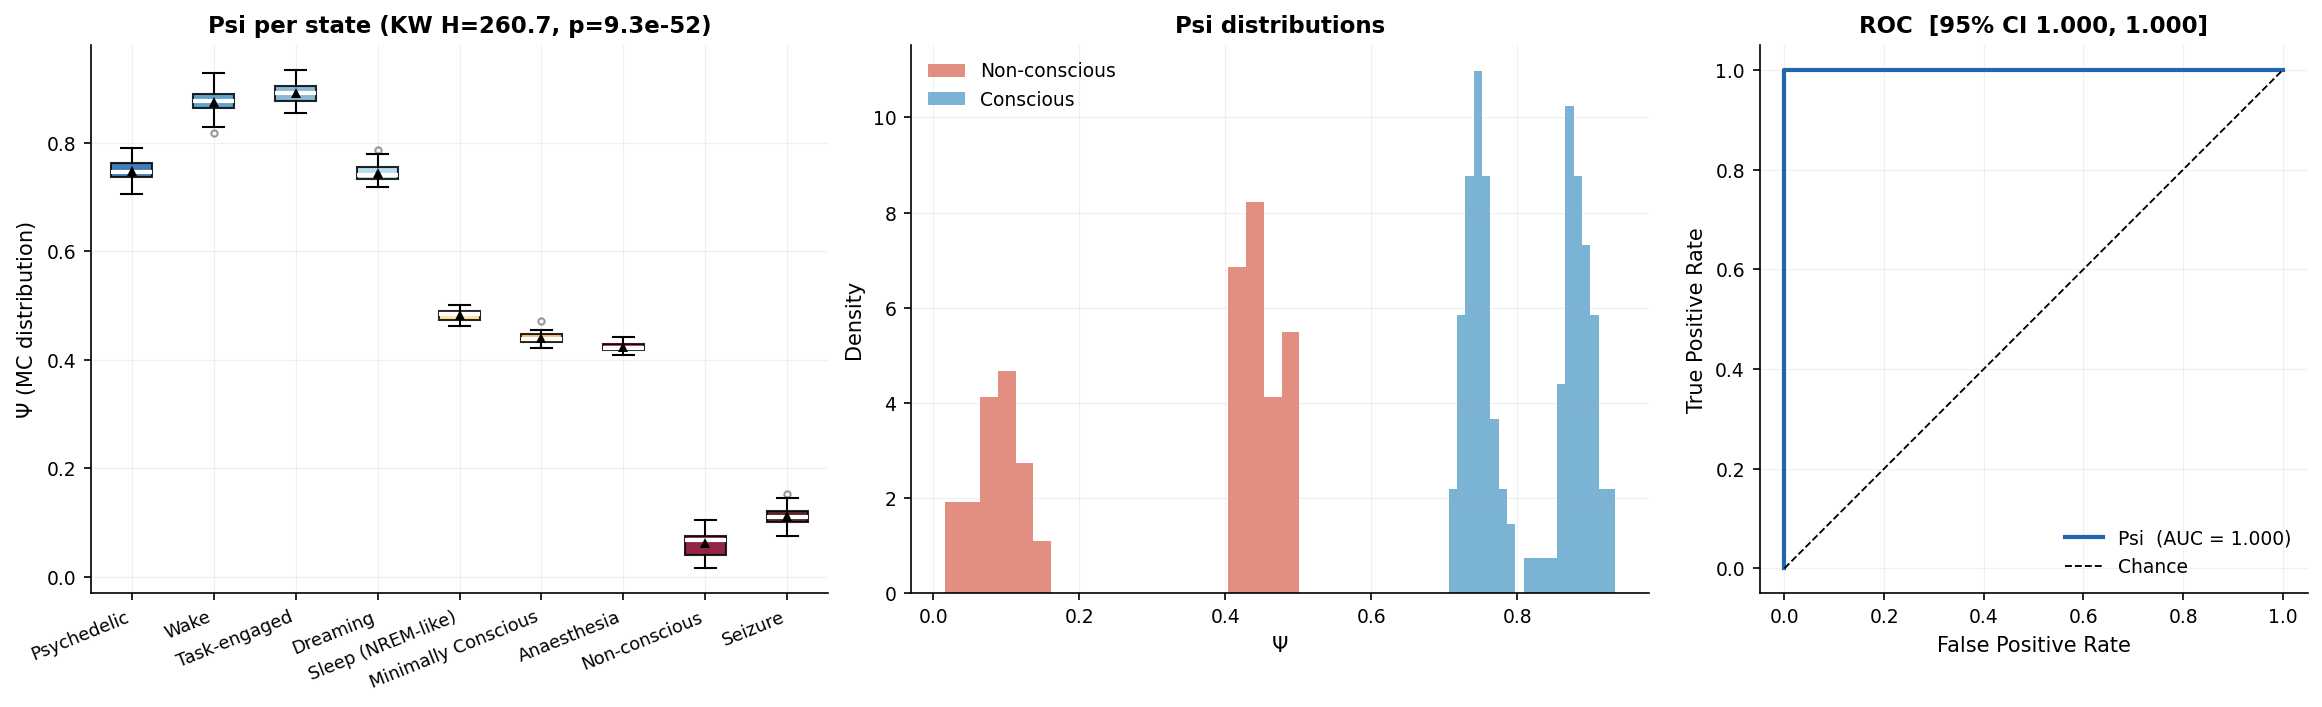

In [22]:
# ── Plot A: per-state Psi distributions + ROC curve + histogram ───────────
PALETTE = {"Psychedelic":"#2166AC","Wake":"#4393C3","Task-engaged":"#74ADD1",
           "Dreaming":"#ABD9E9","Sleep (NREM-like)":"#FEE090",
           "Minimally Conscious":"#FDAE61","Anaesthesia":"#B2182B",
           "Non-conscious":"#800026","Seizure":"#3B0005"}
colors_order = [PALETTE[s] for s in STATE_ORDER]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

# Panel 1: Box-plot
box_data = [mc_df.loc[mc_df["state"] == s, "PSI_mc"].values for s in STATE_ORDER]
bp = axes[0].boxplot(box_data, patch_artist=True, showmeans=True,
                     meanprops=dict(marker="^", markerfacecolor="k",
                                    markersize=5, markeredgewidth=0),
                     medianprops=dict(color="white", linewidth=2),
                     flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, c in zip(bp["boxes"], colors_order):
    patch.set_facecolor(c); patch.set_alpha(0.85)
axes[0].set_xticklabels(STATE_ORDER, rotation=22, ha="right", fontsize=8.5)
axes[0].set_ylabel(r"$\Psi$ (MC distribution)")
axes[0].set_title(f"Psi per state (KW H={H_kw:.1f}, p={p_kw:.1e})")

# Panel 2: Histogram
axes[1].hist(rnc["PSI_mc"], bins=20, alpha=0.7, color="#D6604D",
             density=True, label="Non-conscious")
axes[1].hist(rc["PSI_mc"],  bins=20, alpha=0.7, color="#4393C3",
             density=True, label="Conscious")
axes[1].set_xlabel(r"$\Psi$")
axes[1].set_ylabel("Density")
axes[1].set_title("Psi distributions")
axes[1].legend(loc="upper left", fontsize=9)

# Panel 3: ROC
axes[2].plot(fpr, tpr, color="#2166AC", lw=2.0,
             label=f"Psi  (AUC = {auc:.3f})")
axes[2].plot([0, 1], [0, 1], "k--", lw=0.9, label="Chance")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title(f"ROC  [95% CI {ci_lo:.3f}, {ci_hi:.3f}]")
axes[2].set_aspect("equal")
axes[2].legend(loc="lower right", fontsize=9)

plt.show()


In [23]:
# ── Benchmarking: individual components + simple baselines ────────────────
# AUC for conscious vs non-conscious using each component / baseline alone.

def _lzc_broadband(X, fs):
    """Normalised LZC of broadband (1-40 Hz) amplitude envelope."""
    broad = filtfilt(*butter(4, [1/(fs/2), 40/(fs/2)], btype="band"), X, axis=-1)
    env = np.abs(hilbert(broad, axis=-1))
    out = []
    for ch in range(X.shape[0]):
        e  = env[ch]; ez = (e - np.median(e)) / (np.std(e) + 1e-9)
        s  = "".join("1" if v > 0 else "0" for v in ez)
        n  = len(s); i, k, l, c = 0, 1, 1, 1
        while True:
            if i + k > n: c += 1; break
            if s[:l].find(s[i:i+k]) == -1:
                c += 1; l += k; i = l; k = 1
                if l + 1 > n: break
            else:
                k += 1
                if i + k > n: c += 1; break
        out.append(c / (n / (np.log2(n) + 1e-9) + 1e-9))
    return float(np.mean(out))


def _spectral_slope(X, fs):
    """Aperiodic spectral slope (2-45 Hz log-log slope)."""
    slopes = []
    for ch in range(X.shape[0]):
        f, psd = welch(X[ch], fs=fs, nperseg=min(512, X.shape[1] // 2))
        mask = (f >= 2) & (f <= 45)
        if mask.sum() < 3: continue
        slopes.append(np.polyfit(np.log10(f[mask]), np.log10(psd[mask] + 1e-12), 1)[0])
    return float(np.mean(slopes)) if slopes else np.nan


def _alpha_power(X, fs):
    """Relative alpha (8-13 Hz) band power."""
    vals = []
    for ch in range(X.shape[0]):
        f, psd = welch(X[ch], fs=fs, nperseg=min(512, X.shape[1] // 2))
        tot  = np.trapezoid(psd[(f >= 1) & (f <= 45)], f[(f >= 1) & (f <= 45)])
        alph = np.trapezoid(psd[(f >= 8) & (f <= 13)], f[(f >= 8) & (f <= 13)])
        vals.append(alph / (tot + 1e-12))
    return float(np.mean(vals))


# Aligned rows-labels construction (conscious rows first, then non-conscious)
CONSCIOUS_MC     = {"wake", "task_engaged", "psychedelic"}
NONCONSCIOUS_MC  = {"anesthesia", "non_conscious"}
rows_c  = mc_df[mc_df["state_raw"].isin(CONSCIOUS_MC)].copy()
rows_nc = mc_df[mc_df["state_raw"].isin(NONCONSCIOUS_MC)].copy()
rows_bench = pd.concat([rows_c, rows_nc], ignore_index=True)
y_bench = np.concatenate([np.ones(len(rows_c)), np.zeros(len(rows_nc))])

rng_bm = np.random.default_rng(99)
def boot_auc(y, scores, n=1000):
    aucs = []
    for _ in range(n):
        idx = rng_bm.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2: continue
        aucs.append(roc_auc_score(y[idx], scores[idx]))
    a = roc_auc_score(y, scores)
    lo, hi = (np.percentile(aucs, [2.5, 97.5]) if aucs else (np.nan, np.nan))
    return a, lo, hi

print("="*60)
print("COMPONENT-NECESSITY BENCHMARKING")
print("="*60)
print(f"Conscious states     : {sorted(CONSCIOUS_MC)}  (n={len(rows_c)})")
print(f"Non-conscious states : {sorted(NONCONSCIOUS_MC)}  (n={len(rows_nc)})")
print()
print("AUC (conscious vs non-conscious):")
for label, col in [("H_eff alone",     "H_eff"),
                   ("D alone",         "D"),
                   ("M alone",         "M"),
                   ("Psi (composite)", "PSI_mc")]:
    a, lo, hi = boot_auc(y_bench, rows_bench[col].values)
    print(f"  {label:20s}  AUC = {a:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")

# Add simple baselines — compute LZC / slope / alpha for every MC row
# (fresh simulations needed because mc_df only stored H/D/M)
print("\nComputing simple baselines (LZC, spectral slope, alpha power)...")
print("  (~1 min — 270 additional metric calls on the same ensemble)")

baseline_rows = []
for st in mc_states:
    for _ in range(N_RUNS_PER_STATE):
        X = simulate_state_fast(n_channels=16, T=3000, fs=CFG["fs"], state=st)
        baseline_rows.append({
            "state_raw":   st,
            "LZC":         _lzc_broadband(X, CFG["fs"]),
            "spec_slope":  _spectral_slope(X, CFG["fs"]),
            "alpha_power": _alpha_power(X, CFG["fs"]),
        })
baseline_df = pd.DataFrame(baseline_rows)
b_c  = baseline_df[baseline_df["state_raw"].isin(CONSCIOUS_MC)]
b_nc = baseline_df[baseline_df["state_raw"].isin(NONCONSCIOUS_MC)]
b_rows = pd.concat([b_c, b_nc], ignore_index=True)
y_b = np.concatenate([np.ones(len(b_c)), np.zeros(len(b_nc))])

for label, col in [("LZC broadband",  "LZC"),
                   ("Spectral slope", "spec_slope"),
                   ("Alpha power",    "alpha_power")]:
    a, lo, hi = boot_auc(y_b, b_rows[col].values)
    print(f"  {label:20s}  AUC = {a:.3f}   95% CI [{lo:.3f}, {hi:.3f}]")


COMPONENT-NECESSITY BENCHMARKING
Conscious states     : ['psychedelic', 'task_engaged', 'wake']  (n=90)
Non-conscious states : ['anesthesia', 'non_conscious']  (n=60)

AUC (conscious vs non-conscious):
  H_eff alone           AUC = 1.000   95% CI [1.000, 1.000]
  D alone               AUC = 1.000   95% CI [1.000, 1.000]
  M alone               AUC = 1.000   95% CI [1.000, 1.000]
  Psi (composite)       AUC = 1.000   95% CI [1.000, 1.000]

Computing simple baselines (LZC, spectral slope, alpha power)...
  (~1 min — 270 additional metric calls on the same ensemble)
  LZC broadband         AUC = 1.000   95% CI [1.000, 1.000]
  Spectral slope        AUC = 0.980   95% CI [0.959, 0.995]
  Alpha power           AUC = 0.872   95% CI [0.812, 0.920]


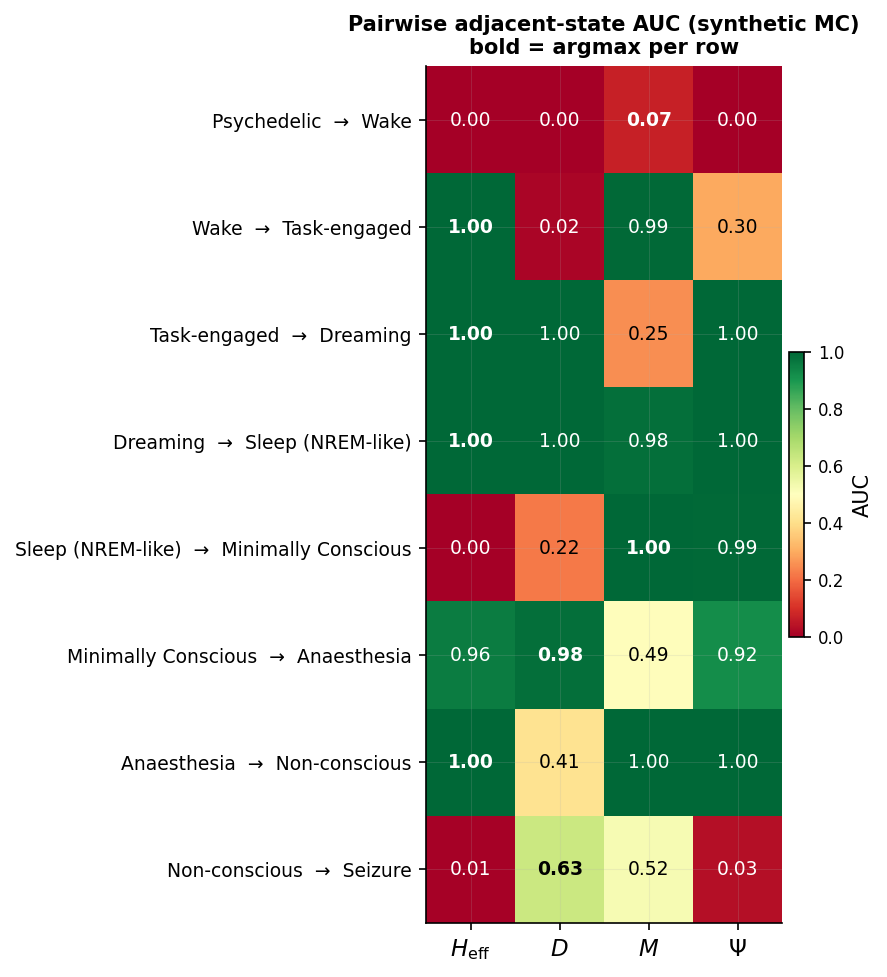

In [24]:
# ── Fig 6: Pairwise adjacent-state AUC heatmap (synthetic MC) ──────────────
adj_pairs = [
    ("Psychedelic",         "Wake"),
    ("Wake",                "Task-engaged"),
    ("Task-engaged",        "Dreaming"),
    ("Dreaming",            "Sleep (NREM-like)"),
    ("Sleep (NREM-like)",   "Minimally Conscious"),
    ("Minimally Conscious", "Anaesthesia"),
    ("Anaesthesia",         "Non-conscious"),
    ("Non-conscious",       "Seizure"),
]
metrics_fig6 = [("H_eff_n", r"$H_{\mathrm{eff}}$"),
                ("D_n",     r"$D$"),
                ("M_n",     r"$M$"),
                ("PSI_mc",  r"$\Psi$")]
row_labels = [f"{a}  \u2192  {b}" for a, b in adj_pairs]

auc_mat = np.full((len(adj_pairs), len(metrics_fig6)), np.nan)
for pi, (s1, s2) in enumerate(adj_pairs):
    r1 = mc_df[mc_df["state"] == s1]
    r2 = mc_df[mc_df["state"] == s2]
    if len(r1) < 2 or len(r2) < 2:
        continue
    yp  = np.concatenate([np.ones(len(r1)), np.zeros(len(r2))])
    rb  = pd.concat([r1, r2], ignore_index=True)
    for mi, (col, _) in enumerate(metrics_fig6):
        try:
            auc_mat[pi, mi] = roc_auc_score(yp, rb[col].values)
        except Exception:
            pass

fig6, ax6 = plt.subplots(figsize=(5.8, 6.4), constrained_layout=True)
im = ax6.imshow(auc_mat, vmin=0.0, vmax=1.0, cmap="RdYlGn", aspect="auto")
ax6.set_xticks(range(len(metrics_fig6)))
ax6.set_xticklabels([m[1] for m in metrics_fig6], fontsize=11)
ax6.set_yticks(range(len(adj_pairs)))
ax6.set_yticklabels(row_labels, fontsize=9)
for pi in range(len(adj_pairs)):
    row = auc_mat[pi]
    best_idx = int(np.nanargmax(row)) if not np.all(np.isnan(row)) else -1
    for mi in range(len(metrics_fig6)):
        v = auc_mat[pi, mi]
        if np.isnan(v): continue
        ax6.text(mi, pi, f"{v:.2f}", ha="center", va="center",
                 fontsize=9, fontweight="bold" if mi == best_idx else "normal",
                 color="white" if (v > 0.85 or v < 0.15) else "black")
cb = plt.colorbar(im, ax=ax6, label="AUC", fraction=0.04, pad=0.02, shrink=0.85)
cb.ax.tick_params(labelsize=8)
ax6.set_title("Pairwise adjacent-state AUC (synthetic MC)\n"
              "bold = argmax per row",
              fontsize=10)
plt.show()
plt.close(fig6)


## Section B — Ablation study

We now verify that each of the three components contributes independently
to $\Psi$. We start from the Wake simulator (which gives $H_{\mathrm{eff}}$
near its maximum and non-zero $D$ and $M$), then ablate exactly one
component at a time:

- **No PAC** — remove $\gamma$-band content, so $I_{\varphi,A} \to 0$ and $D \to 0$.
- **No Metastability** — tile channel 0 across every channel, so $R(t) \to 1$ and $M \to 0$.
- **No Fractal** — set $H_{\mathrm{raw}} = 1.5$, pushing $\alpha_{\mathrm{dfa}}$ far from $H_{\mathrm{opt}}$ so $H_{\mathrm{eff}} = 0$.

Normalisation uses `NORM_REF` from the Monte Carlo run above, so the bars
reflect the SAME scale as the manuscript figures.


In [25]:
# ── Ablation study: Baseline / No PAC / No Metastability / No Fractal ────

def run_ablation_tests(C=16, T=7500, fs=250,
                        Hopt=0.35, sigma_H=0.12, lam=1.0, n_runs=10):
    """Ablation study with simulate_state_fast('wake') as the baseline.

    Each ablation removes exactly one component; the others are unchanged.
    """
    condition_ids = ["baseline", "no_pac", "no_metastability", "no_fractal"]
    all_results = {cid: [] for cid in condition_ids}

    for _ in range(n_runs):
        # Baseline — full wake signal
        X = simulate_state_fast(state="wake", n_channels=C, T=T, fs=fs)
        m = compute_metrics(X, fs=fs, Hopt=Hopt, sigma_H=sigma_H, lam=lam)
        all_results["baseline"].append(m)

        # No PAC — remove gamma band (no phase-amplitude coupling structure)
        X_np = simulate_state_fast(state="wake", n_channels=C, T=T, fs=fs)
        b, a = butter(4, [30/(fs/2), 80/(fs/2)], btype="band")
        gamma_component = filtfilt(b, a, X_np, axis=-1)
        X_np = X_np - gamma_component
        m_np = compute_metrics(X_np, fs=fs, Hopt=Hopt, sigma_H=sigma_H, lam=lam)
        all_results["no_pac"].append(m_np)

        # No Metastability — tile channel 0 across every channel (R(t) = 1)
        X_nm = simulate_state_fast(state="wake", n_channels=C, T=T, fs=fs)
        X_nm_sync = np.tile(X_nm[0:1, :], (C, 1))
        m_nm = compute_metrics(X_nm_sync, fs=fs, Hopt=Hopt,
                                sigma_H=sigma_H, lam=lam)
        all_results["no_metastability"].append(m_nm)

        # No Fractal — keep D and M as baseline, force H_eff = 0
        X_nf = simulate_state_fast(state="wake", n_channels=C, T=T, fs=fs)
        m_nf = compute_metrics(X_nf, fs=fs, Hopt=Hopt, sigma_H=sigma_H, lam=lam)
        m_nf["H_raw"] = 1.5
        m_nf["Heff"]  = 0.0
        m_nf["Psi"]   = w_H*0.0 + w_D*m_nf["D"] + w_M*m_nf["M"]
        all_results["no_fractal"].append(m_nf)

    summary = {}
    for cid in condition_ids:
        H = np.array([r["Heff"] for r in all_results[cid]])
        D = np.array([r["D"]   for r in all_results[cid]])
        M = np.array([r["M"]   for r in all_results[cid]])
        P = np.array([r["Psi"] for r in all_results[cid]])
        summary[cid] = {
            "Heff_mean": H.mean(), "Heff_std": H.std(),
            "D_mean":    D.mean(), "D_std":    D.std(),
            "M_mean":    M.mean(), "M_std":    M.std(),
            "Psi_mean":  P.mean(), "Psi_std":  P.std(),
        }
    return summary


print("Running ablation study (10 runs per condition × 4 conditions)...")
ablation_summary = run_ablation_tests(
    C=16, T=7500, fs=CFG["fs"], Hopt=CFG["H_opt"],
    sigma_H=CFG["sigma_H"], lam=CFG["lam"], n_runs=10,
)

# Print summary table
print("\nAblation summary (mean ± SD):")
print(f"{'Condition':<20s} {'H_eff':>14s} {'D':>14s} {'M':>14s} {'Psi':>14s}")
for cid in ["baseline", "no_pac", "no_metastability", "no_fractal"]:
    s = ablation_summary[cid]
    print(f"{format_label(cid):<20s} "
          f"{s['Heff_mean']:>6.3f}±{s['Heff_std']:<5.3f}  "
          f"{s['D_mean']:>6.3f}±{s['D_std']:<5.3f}  "
          f"{s['M_mean']:>6.3f}±{s['M_std']:<5.3f}  "
          f"{s['Psi_mean']:>6.3f}±{s['Psi_std']:<5.3f}")


Running ablation study (10 runs per condition × 4 conditions)...

Ablation summary (mean ± SD):
Condition                     H_eff              D              M            Psi
Baseline              0.812±0.013   0.014±0.001   0.223±0.007   0.385±0.005
No Pac                0.856±0.012   0.002±0.000   0.223±0.007   0.399±0.005
No Metastability      0.801±0.030   0.015±0.002   0.000±0.000   0.325±0.012
No Fractal            0.000±0.000   0.014±0.001   0.227±0.006   0.062±0.002


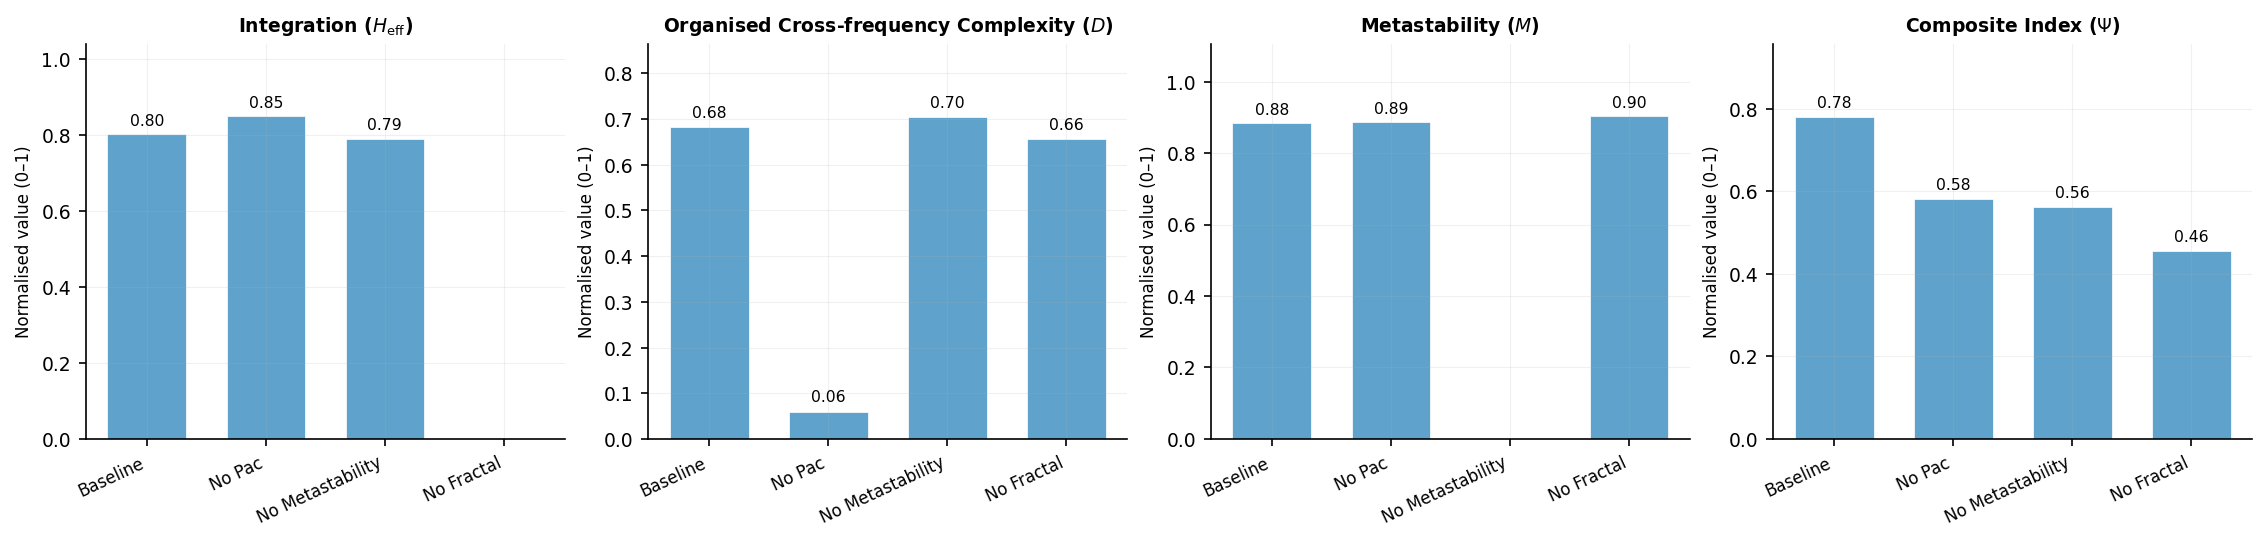

In [26]:
# ── Ablation plot: normalised by NORM_REF for comparability with main figs ──
def plot_ablation_results(summary, norm_ref=None):
    condition_ids = ["baseline", "no_pac", "no_metastability", "no_fractal"]
    labels = [format_label(cid) for cid in condition_ids]
    titles = [r"Integration ($H_\mathrm{eff}$)",
              r"Organised Cross-frequency Complexity ($D$)",
              r"Metastability ($M$)",
              r"Composite Index ($\Psi$)"]

    if norm_ref is not None:
        # Normalise to NORM_REF so ablated components sit visibly at 0
        for cid in condition_ids:
            h_n = float(np.clip(
                (summary[cid]["Heff_mean"] - norm_ref["H_eff"][0]) /
                (norm_ref["H_eff"][1] - norm_ref["H_eff"][0] + 1e-12), 0, 1))
            d_n = float(np.clip(
                (summary[cid]["D_mean"] - norm_ref["D"][0]) /
                (norm_ref["D"][1] - norm_ref["D"][0] + 1e-12), 0, 1))
            m_n = float(np.clip(
                (summary[cid]["M_mean"] - norm_ref["M"][0]) /
                (norm_ref["M"][1] - norm_ref["M"][0] + 1e-12), 0, 1))
            summary[cid]["Heff_n"] = h_n
            summary[cid]["D_n"]    = d_n
            summary[cid]["M_n"]    = m_n
            summary[cid]["Psi_norm"] = w_H*h_n + w_D*d_n + w_M*m_n
        plot_keys = ["Heff_n", "D_n", "M_n", "Psi_norm"]
        ylbl = "Normalised value (0–1)"
    else:
        plot_keys = ["Heff_mean", "D_mean", "M_mean", "Psi_mean"]
        ylbl = "Value"

    fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), constrained_layout=True)
    x = np.arange(len(condition_ids))
    for ax, pk, title in zip(axes, plot_keys, titles):
        vals = [summary[cid][pk] for cid in condition_ids]
        ax.bar(x, vals, width=0.66, color="#4393C3",
               alpha=0.85, edgecolor="white", linewidth=0.4)
        for xi, v in enumerate(vals):
            if v > 0.005:
                ax.text(xi, v + 0.015, f"{v:.2f}",
                        ha="center", va="bottom", fontsize=7.5)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
        ax.set_ylim(0, max(vals) * 1.20 + 0.02)
        ax.set_title(title, fontsize=9)
        ax.set_ylabel(ylbl, fontsize=8)
    return fig


_fig_abl = plot_ablation_results(ablation_summary, norm_ref=NORM_REF)
plt.show()
plt.close(_fig_abl)


## Section C — Hyperparameter sensitivity analysis

Three sweeps over the tuning parameters, measured by the **adjacent-pair
AUC** metric (mean and minimum across 7 adjacent state pairs in the
hierarchy, orientation-corrected so direction flips don't penalise):

1. $H_{\mathrm{opt}}$ — the DFA α midpoint of the triangular tuning.
2. $w_H$ — the composite weight on $H_{\mathrm{eff}}$ (with $w_D$:$w_M$
   ratio held constant at the nominal 0.35 : 0.25).
3. $\lambda$ — the weight on LZ inside $D = I_{\varphi,A}\,(1+\lambda\,\mathrm{LZ})$.

The first two sweeps are fast (recompute $\Psi$ from the stored MC
ensemble). The $\lambda$ sweep requires fresh simulations because the LZ
weight is baked in at metric-computation time. Runtime: ~1–2 minutes.


Sweeping H_opt...
Sweeping w_H...
Sweeping lambda (requires fresh simulations)...
  lambda=0.4: mean AUC=0.920, min AUC=0.594
  lambda=0.6: mean AUC=0.960, min AUC=0.859
  lambda=0.8: mean AUC=0.973, min AUC=0.906
  lambda=1.0: mean AUC=0.960, min AUC=0.750
  lambda=1.2: mean AUC=0.971, min AUC=0.875
  lambda=1.4: mean AUC=0.980, min AUC=0.875
  lambda=1.6: mean AUC=0.938, min AUC=0.797
  lambda=1.8: mean AUC=0.955, min AUC=0.703
  lambda=2.0: mean AUC=0.935, min AUC=0.750


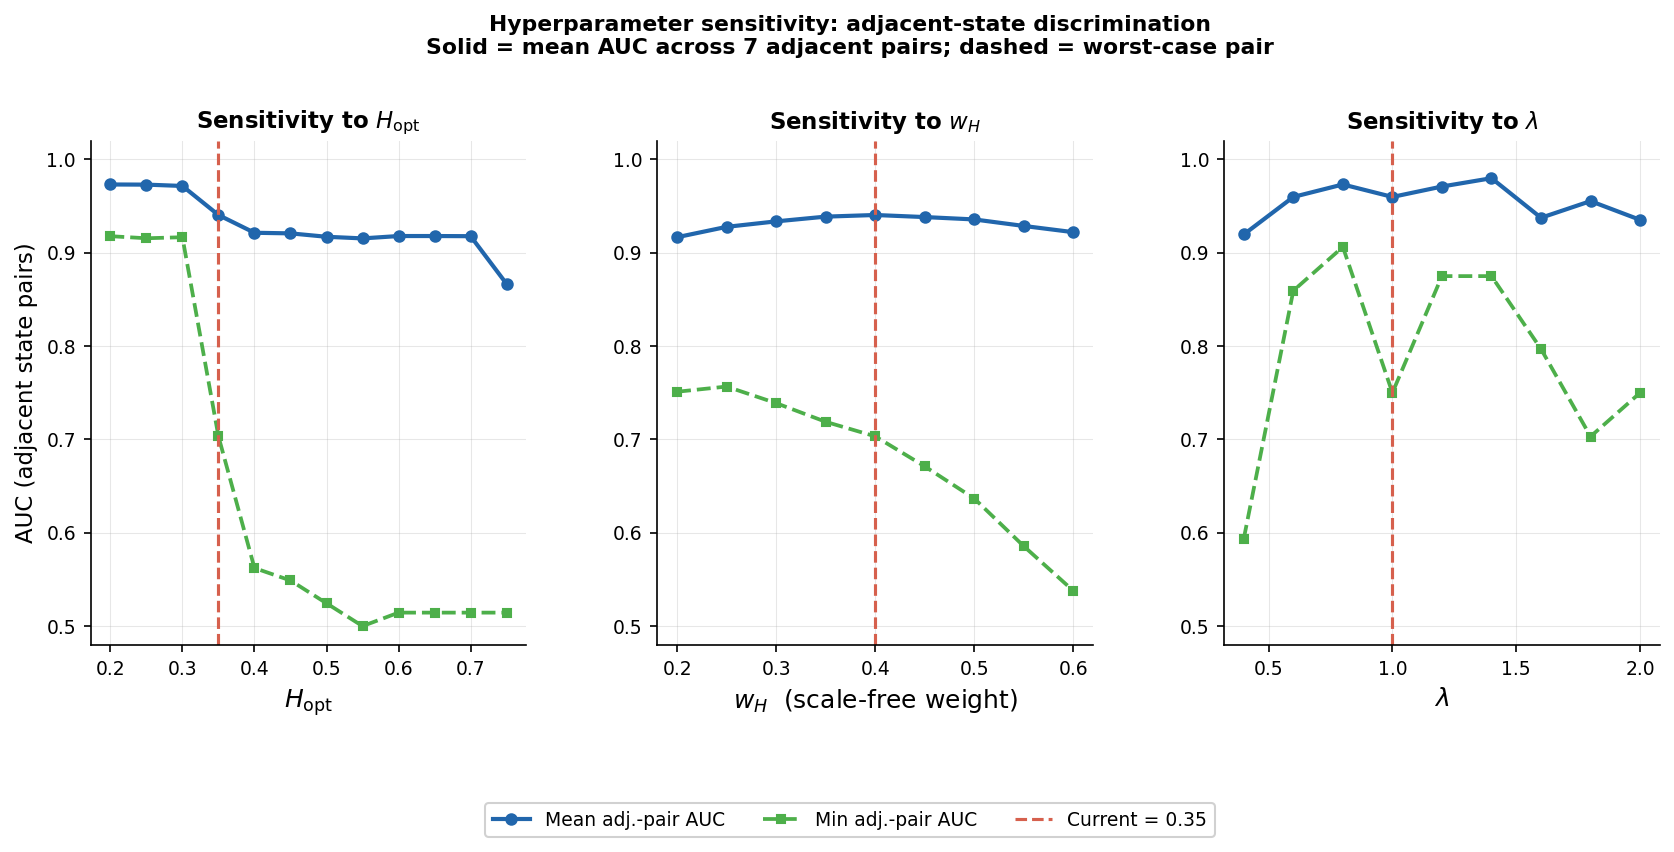

In [27]:
# ── Sensitivity analysis: 3 panels (H_opt, w_H, lambda) ───────────────────

ADJ_PAIRS_SENS = [
    ("Wake",                "Task-engaged"),
    ("Task-engaged",        "Dreaming"),
    ("Dreaming",            "Sleep (NREM-like)"),
    ("Sleep (NREM-like)",   "Minimally Conscious"),
    ("Minimally Conscious", "Anaesthesia"),
    ("Anaesthesia",         "Non-conscious"),
    ("Non-conscious",       "Seizure"),
]
_STATES_LAM = ["wake","task_engaged","psychedelic","dreaming",
               "sleep","minimally_conscious","anesthesia",
               "non_conscious","seizure"]
_LABEL_MAP  = STATE_DISPLAY   # reuse the display map


def adj_auc_summary(df_in, psi_col):
    """Mean and minimum orientation-corrected AUC across adjacent pairs."""
    aucs = []
    for s1, s2 in ADJ_PAIRS_SENS:
        r1 = df_in[df_in["state"] == s1]
        r2 = df_in[df_in["state"] == s2]
        if len(r1) < 2 or len(r2) < 2:
            continue
        y    = np.concatenate([np.ones(len(r1)), np.zeros(len(r2))])
        vals = pd.concat([r1[[psi_col]], r2[[psi_col]]], ignore_index=True)[psi_col].values
        try:
            a = float(roc_auc_score(y, vals))
            aucs.append(max(a, 1.0 - a))  # orientation-corrected
        except Exception:
            pass
    if not aucs:
        return np.nan, np.nan
    return float(np.mean(aucs)), float(np.min(aucs))


def recompute_psi(df_src, Hopt_new, wH, wD, wM):
    """Recompute Psi from stored D_n, M_n with a new H_opt and weights."""
    df = df_src.copy()
    df["_H_eff"] = df["H"].apply(
        lambda a: max(0.0, 1.0 - abs(a - Hopt_new) / _alpha_range_mc))
    hmin, hmax = df["_H_eff"].min(), df["_H_eff"].max()
    df["_H_n"] = (df["_H_eff"] - hmin) / (hmax - hmin + 1e-9)
    df["_PSI"] = wH*df["_H_n"] + wD*df["D_n"] + wM*df["M_n"]
    return df


# ── Panel 1: H_opt sweep (fast) ──────────────────────────────────────────
print("Sweeping H_opt...")
h_opts = np.round(np.arange(0.20, 0.76, 0.05), 2)
mean_h, min_h = [], []
for h in h_opts:
    df_s = recompute_psi(mc_df, h, w_H, w_D, w_M)
    m, mn = adj_auc_summary(df_s, "_PSI")
    mean_h.append(m); min_h.append(mn)

# ── Panel 2: w_H sweep (fast) ────────────────────────────────────────────
print("Sweeping w_H...")
wH_vals = np.round(np.arange(0.20, 0.61, 0.05), 2)
_D_ratio = w_D / (w_D + w_M); _M_ratio = w_M / (w_D + w_M)
mean_w, min_w = [], []
for wh in wH_vals:
    rem = 1.0 - wh
    df_s = recompute_psi(mc_df, H_opt, wh, rem*_D_ratio, rem*_M_ratio)
    m, mn = adj_auc_summary(df_s, "_PSI")
    mean_w.append(m); min_w.append(mn)

# ── Panel 3: lambda sweep (slow; fresh simulations needed) ───────────────
print("Sweeping lambda (requires fresh simulations)...")
lambda_vals = np.round(np.arange(0.4, 2.01, 0.2), 1)
N_QUICK = 8  # lighter than MC to keep runtime manageable
mean_l, min_l = [], []
for lv in lambda_vals:
    rows = []
    for st in _STATES_LAM:
        for _ in range(N_QUICK):
            X = simulate_state_fast(n_channels=16, T=3000, fs=250, state=st)
            m = compute_metrics(X, fs=250, Hopt=H_opt, sigma_H=CFG["sigma_H"],
                                lam=float(lv), alpha_range=_alpha_range_mc)
            rows.append({"state": _LABEL_MAP[st], "Psi": m["Psi"]})
    df_lam = pd.DataFrame(rows)
    m, mn = adj_auc_summary(df_lam, "Psi")
    mean_l.append(m); min_l.append(mn)
    print(f"  lambda={lv}: mean AUC={m:.3f}, min AUC={mn:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────────
def _panel(ax, xs, m_vals, n_vals, cur_x, xlabel, title, legend_label, show_ylabel=False):
    ax.plot(xs, m_vals, "o-", color="#2166AC", lw=2, ms=5,
            label="Mean adj.-pair AUC")
    ax.plot(xs, n_vals, "s--", color="#4DAF4A", lw=1.8, ms=4,
            label="Min adj.-pair AUC")
    ax.axvline(cur_x, color="#D6604D", ls="--", lw=1.5, label=legend_label)
    ax.set_xlabel(xlabel, fontsize=12)
    if show_ylabel:
        ax.set_ylabel("AUC (adjacent state pairs)", fontsize=11)
    ax.set_ylim(0.48, 1.02)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)


figB, axsB = plt.subplots(1, 3, figsize=(13.5, 5.6))
figB.subplots_adjust(bottom=0.22, top=0.82, wspace=0.30)

_panel(axsB[0], h_opts, mean_h, min_h, H_opt,
       r"$H_{\mathrm{opt}}$", r"Sensitivity to $H_{\mathrm{opt}}$",
       f"Current = {H_opt}", show_ylabel=True)
_panel(axsB[1], wH_vals, mean_w, min_w, w_H,
       r"$w_H$  (scale-free weight)", r"Sensitivity to $w_H$",
       f"Current = {w_H}")
_panel(axsB[2], lambda_vals, mean_l, min_l, lam,
       r"$\lambda$", r"Sensitivity to $\lambda$",
       f"Current = {lam}")

handles, labels = axsB[0].get_legend_handles_labels()
figB.legend(handles, labels, loc="lower center",
            bbox_to_anchor=(0.5, -0.02), ncol=3, fontsize=9,
            frameon=True, framealpha=0.9)
figB.suptitle("Hyperparameter sensitivity: adjacent-state discrimination\n"
              "Solid = mean AUC across 7 adjacent pairs; dashed = worst-case pair",
              fontsize=10.5, fontweight="bold", y=0.97)
plt.show()
plt.close(figB)


## Section D — Within-state Monte Carlo convergence

This diagnostic shows how quickly each state's running mean approaches its
long-run mean as the number of MC runs grows. We use within-state
convergence (not pooled) because pooled convergence conflates between-state
variance with MC noise. The `n = 30` guide line marks the choice used in
the paper and in Section A above.


Running 50 within-state MC runs per state for convergence diagnostic...
  Psychedelic: 50 / 50 runs succeeded
  Wake: 50 / 50 runs succeeded
  Task-engaged: 50 / 50 runs succeeded
  Dreaming: 50 / 50 runs succeeded
  Sleep (NREM-like): 50 / 50 runs succeeded
  Minimally Conscious: 50 / 50 runs succeeded
  Anaesthesia: 50 / 50 runs succeeded
  Non-conscious: 50 / 50 runs succeeded
  Seizure: 50 / 50 runs succeeded


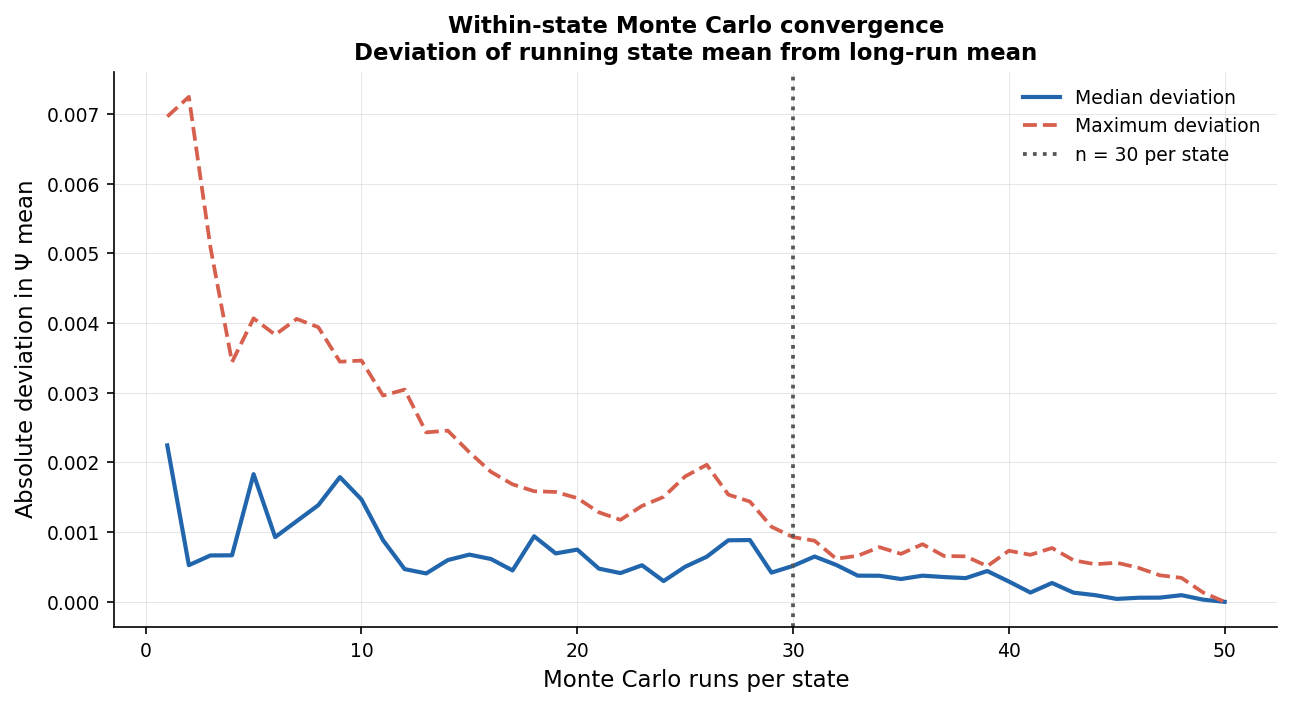

In [28]:
# ── Fig : within-state MC convergence ────────────────────────────────────
print("Running 50 within-state MC runs per state for convergence diagnostic...")

N_CONV = 50
state_runs = {}
_key = {v: k for k, v in STATE_DISPLAY.items()}

for state in STATE_ORDER:
    sk = _key[state]
    vals = []
    for _ in range(N_CONV):
        try:
            X = simulate_state_fast(n_channels=16, T=5000, fs=250, state=sk)
            m = compute_metrics(X, fs=250, Hopt=H_opt,
                                sigma_H=CFG["sigma_H"], lam=lam)
            vals.append(m["Psi"])
        except Exception:
            pass
    state_runs[state] = np.array(vals, dtype=float)
    print(f"  {state}: {len(vals)} / {N_CONV} runs succeeded")

max_len = min((len(v) for v in state_runs.values() if len(v) > 0), default=0)
if max_len >= 2:
    xs = np.arange(1, max_len + 1)
    dev_mat = []
    for state in STATE_ORDER:
        v = state_runs[state][:max_len]
        if len(v) == 0: continue
        final_mean = float(np.mean(v))
        running_m  = np.array([np.mean(v[:n]) for n in xs])
        dev_mat.append(np.abs(running_m - final_mean))
    dev_mat    = np.array(dev_mat)
    median_dev = np.median(dev_mat, axis=0)
    max_dev    = np.max(dev_mat, axis=0)

    figC, axC = plt.subplots(figsize=(8.5, 4.6), constrained_layout=True)
    axC.plot(xs, median_dev, color="#2166AC", lw=2, label="Median deviation")
    axC.plot(xs, max_dev,    color="#D6604D", lw=1.8, ls="--", label="Maximum deviation")
    axC.axvline(30, color="#555555", ls=":", lw=1.8, label="n = 30 per state")
    axC.set_xlabel("Monte Carlo runs per state", fontsize=11)
    axC.set_ylabel(r"Absolute deviation in $\Psi$ mean", fontsize=11)
    axC.set_title("Within-state Monte Carlo convergence\n"
                  "Deviation of running state mean from long-run mean",
                  fontsize=11, fontweight="bold")
    axC.grid(alpha=0.3)
    axC.legend(fontsize=9)
    plt.show()
    plt.close(figC)
else:
    print("Insufficient runs for convergence plot.")


## Section E — Sleep-EDF empirical validation

The Sleep-EDF Cassette EEG data is read **from the local `DATA_DIR`** —
no network download, no MNE fetcher. Point `DATA_DIR` at the folder
containing your pre-downloaded `*-PSG.edf` and `*-Hypnogram.edf` files.

Pipeline:
- Extract 30-second Wake / N2 / REM epochs per subject (stratified across the night).
- Compute Ψ and the benchmark metrics on each epoch.
- Per-subject $H_{\mathrm{opt}}$ calibration by KDE mode of that subject's own Wake α_{\mathrm{dfa}} — a domain-adaptation of the tuning prior, not a fit to the test data.
- **Friedman** omnibus across the three stages (paired over subjects).
- **Wilcoxon signed-rank** with Bonferroni correction for post-hoc pairs.
- **Subject-level AUC** with 95% bootstrap CIs (resampling over subjects).
- **Figure 7** — subject-level Ψ per stage with significance brackets.
- **Figure 8** — AUC benchmarking heatmap (Ψ vs single-component and baseline metrics).

`N_SUBJ = 30` reproduces the manuscript values; lower it for a quick
sanity-check run.

**Heads-up on two-channel limitations.** Sleep-EDF has 2 EEG channels, so
$D$ and $M$ collapse toward zero — Ψ in real EEG is effectively driven by
$H_{\mathrm{eff}}$. The per-stage component-contribution printout makes
this transparent.


In [29]:
# ── Sleep-EDF empirical validation helpers ────────────────────────────────
# These are the shared helpers used by the main Sleep-EDF pipeline.
# Each operates on a DataFrame of epoch-level metrics with columns including
# subject, stage, H, D, M, H_eff, PSI, and optionally LZC / spec_slope / alpha_power.


def compute_pac_surrogate(X, fs, n_surrogates=50, gamma_high=45):
    """Time-shift surrogate test for PAC significance.

    Shifts gamma amplitude by a random time offset relative to theta phase.
    Returns (obs_mi, surr_mean, surr_sd, z_score).
    z > 2 indicates PAC significantly above chance.
    """
    theta = filtfilt(*butter(4, [4/(fs/2), 8/(fs/2)], btype="band"), X, axis=-1)
    gamma = filtfilt(*butter(4, [30/(fs/2), gamma_high/(fs/2)], btype="band"),
                     X, axis=-1)
    theta_phase = np.angle(hilbert(theta, axis=-1))
    gamma_amp   = np.abs(hilbert(gamma,  axis=-1))

    def tort_mi(ph, amp, n_bins=36):
        bins = np.linspace(-np.pi, np.pi, n_bins + 1)
        ap = np.array([amp[(ph >= bins[i]) & (ph < bins[i+1])].mean()
                       if ((ph >= bins[i]) & (ph < bins[i+1])).sum() > 0 else 0.0
                       for i in range(n_bins)])
        ap /= ap.sum() + 1e-12
        q = np.ones(n_bins) / n_bins
        return float(np.sum(ap * np.log(ap / q + 1e-12)))

    obs_mi = float(np.mean([tort_mi(theta_phase[ch], gamma_amp[ch])
                             for ch in range(X.shape[0])]))
    T = X.shape[1]
    surr = []
    for _ in range(n_surrogates):
        shift = np.random.randint(T // 4, 3 * T // 4)
        gamma_shifted = np.roll(gamma_amp, shift, axis=-1)
        surr.append(np.mean([tort_mi(theta_phase[ch], gamma_shifted[ch])
                             for ch in range(X.shape[0])]))
    surr_mean = float(np.mean(surr))
    surr_sd   = float(np.std(surr) + 1e-12)
    return obs_mi, surr_mean, surr_sd, (obs_mi - surr_mean) / surr_sd


def wake_mode_kde(wake_alpha, grid_n=512):
    """KDE-based mode of the within-subject Wake alpha_dfa distribution.

    Robust to bimodal clinical Wake distributions where the median can fall
    between clean eyes-closed alpha and drowsy transitional epochs. Falls
    back to median for small n or numerical failures.
    """
    wake_alpha = np.asarray(wake_alpha, dtype=float)
    wake_alpha = wake_alpha[np.isfinite(wake_alpha)]
    if len(wake_alpha) < 3:
        return float(np.median(wake_alpha)) if len(wake_alpha) else float("nan")
    from scipy.stats import gaussian_kde
    try:
        kde = gaussian_kde(wake_alpha, bw_method="scott")
        lo, hi = wake_alpha.min(), wake_alpha.max()
        pad = (hi - lo) * 0.05 if hi > lo else 0.05
        grid = np.linspace(lo - pad, hi + pad, grid_n)
        return float(grid[np.argmax(kde(grid))])
    except Exception:
        return float(np.median(wake_alpha))


def rank_biserial(v1, v2):
    """Matched-pairs rank-biserial correlation for paired Wilcoxon."""
    d = np.asarray(v1) - np.asarray(v2)
    d = d[d != 0]
    if len(d) == 0:
        return 0.0
    r = rankdata(np.abs(d))
    Wp = r[d > 0].sum(); Wn = r[d < 0].sum()
    return float((Wp - Wn) / (Wp + Wn)) if (Wp + Wn) > 0 else 0.0


def paired_stats_table(piv, stages, pairs, label_fn=None, indent="  "):
    """Friedman omnibus + Wilcoxon post-hoc with Bonferroni correction.

    Returns dict {friedman_chi2, friedman_p, friedman_n, pairs:{...}}.
    """
    if label_fn is None:
        label_fn = str
    out = {"friedman_chi2": float("nan"), "friedman_p": float("nan"),
           "friedman_n": 0, "pairs": {}}
    stages_present = [s for s in stages if s in piv.columns]
    complete = piv[stages_present].dropna() if stages_present else piv.iloc[:0]
    n_c = len(complete)
    out["friedman_n"] = n_c
    if n_c >= 3 and len(stages_present) >= 3:
        chi2, p = friedmanchisquare(*[complete[s].values for s in stages_present])
        out["friedman_chi2"] = float(chi2); out["friedman_p"] = float(p)
        print(f"{indent}Friedman (paired, n={n_c} complete-case subjects, "
              f"K={len(stages_present)}): chi2={chi2:.2f}, p={p:.4f}")
    else:
        print(f"{indent}Friedman: insufficient data (n={n_c})")

    if not pairs:
        return out
    bonf = 0.05 / len(pairs)
    print(f"{indent}Pairwise Wilcoxon (Bonferroni alpha={bonf:.4f}):")
    for s1, s2 in pairs:
        if s1 not in piv.columns or s2 not in piv.columns:
            continue
        sh = piv[[s1, s2]].dropna()
        if len(sh) < 4:
            print(f"{indent}  {label_fn(s1):>8s} vs {label_fn(s2):<8s}:"
                  f"  insufficient (n={len(sh)})")
            continue
        v1, v2 = sh[s1].values, sh[s2].values
        _, p = wilcoxon(v1, v2)
        r_rb = rank_biserial(v1, v2)
        sig = ("***" if p < 0.001 else "**" if p < 0.01
               else "*" if p < 0.05 else "ns")
        bonf_sig = p < bonf
        out["pairs"][(s1, s2)] = {"p": float(p), "r_rb": r_rb, "sig": sig,
                                  "n": len(sh), "bonf_sig": bonf_sig,
                                  "bonf_thresh": bonf}
        tag = "(Bonf.sig)" if bonf_sig else ""
        print(f"{indent}  {label_fn(s1):>8s} vs {label_fn(s2):<8s}:"
              f"  p={p:.4f} {sig:>3s}  r_rb={r_rb:+.2f}  n={len(sh)} {tag}")
    return out


def boot_auc_paired(v1, v2, n_boot=2000, seed=42):
    """Bootstrap 95% CI of AUC, resampling paired subjects."""
    rng = np.random.default_rng(seed)
    n = len(v1); boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        v1b, v2b = v1[idx], v2[idx]
        yb   = np.concatenate([np.ones(n), np.zeros(n)])
        vals = np.concatenate([v1b, v2b])
        try:
            boots.append(roc_auc_score(yb, vals))
        except ValueError:
            pass
    if not boots:
        return float("nan"), float("nan")
    return (float(np.percentile(boots, 2.5)),
            float(np.percentile(boots, 97.5)))


def subject_auc_benchmark(df, pairs, bench_cols, subject_col="subject",
                           stage_col="stage", n_boot=2000, seed=42,
                           do_print=True, indent="  "):
    """Subject-level AUC benchmarking across paired stages."""
    subj_piv = {}
    for _lbl, col in bench_cols:
        if col in df.columns:
            subj_piv[col] = (df.groupby([subject_col, stage_col])[col]
                               .mean().unstack(stage_col))
    results = {}
    for s1, s2 in pairs:
        if do_print:
            print(f"\n{indent}{s1} vs {s2}:")
        for label, col in bench_cols:
            if col not in subj_piv: continue
            pv = subj_piv[col]
            if s1 not in pv.columns or s2 not in pv.columns: continue
            sh = pv[[s1, s2]].dropna()
            if len(sh) < 4:
                if do_print:
                    print(f"{indent}  {label:22s}  insufficient (n={len(sh)})")
                continue
            v1, v2 = sh[s1].values, sh[s2].values
            y    = np.concatenate([np.ones(len(v1)), np.zeros(len(v2))])
            vals = np.concatenate([v1, v2])
            try:
                a = roc_auc_score(y, vals)
                lo, hi = boot_auc_paired(v1, v2, n_boot=n_boot, seed=seed)
                results[(s1, s2, col)] = (a, lo, hi)
                if do_print:
                    print(f"{indent}  {label:22s}  AUC = {a:.3f}  "
                          f"[{lo:.3f}, {hi:.3f}]  (n={len(v1)} subjects)")
            except Exception as e:
                if do_print:
                    print(f"{indent}  {label:22s}  {e}")
    return results


print("Sleep-EDF helpers loaded: PAC surrogate, KDE mode, paired stats, bootstrap AUC.")


Sleep-EDF helpers loaded: PAC surrogate, KDE mode, paired stats, bootstrap AUC.


In [30]:
# ── Sleep-EDF main pipeline (LOCAL DATA ONLY — no download) ────────────────
# Point DATA_DIR at a folder containing *-PSG.edf and *-Hypnogram.edf files.

import glob

N_SUBJ         = 30     # number of subjects (set lower for quick runs)
N_EPOCHS       = 15     # epochs per stage per subject
EPOCH_DUR_SEC  = 30     # 30-s epochs (AASM standard)
REAL_FS        = 100    # Sleep-EDF Cassette native sampling rate
GAMMA_CAP      = 45     # Hz, below 100 Hz Nyquist

# ────────────────────────────────────────────────────────────────────────
# DATA PATH — adjust this one line for your environment
# ────────────────────────────────────────────────────────────────────────
# On Google Colab, first run:
#from google.colab import drive; drive.mount('/content/drive')

#     DATA_DIR = "./sleep_edf_local"

#Sleep-EDF data sample used is available at: https://drive.google.com/drive/folders/1zRKqwlYfLGn6OTwL4cj6ceRMvfvWjiUY?usp=sharing

DATA_DIR = "/content/drive/MyDrive/...."

STAGES = {"Sleep stage W": "W", "Sleep stage 2": "N2", "Sleep stage R": "R"}


def load_local_pairs(n_subj):
    """Match *-PSG.edf with *-Hypnogram.edf files by 6-char prefix (SC4ssN).

    Sleep-EDF pairs the two file types by subject + night prefix; the
    scorer suffix on the hypnogram varies (e.g. SC4001E0-PSG.edf pairs
    with SC4001EC-Hypnogram.edf).
    """
    if not os.path.isdir(DATA_DIR):
        raise FileNotFoundError(
            f"DATA_DIR not found: {DATA_DIR}\n"
            "Update DATA_DIR at the top of this cell to your local path "
            "containing *-PSG.edf and *-Hypnogram.edf files."
        )
    psg_files = sorted(glob.glob(os.path.join(DATA_DIR, "*PSG.edf")))
    if not psg_files:
        # Try a recursive search in case files are in subfolders
        psg_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*PSG.edf"),
                                      recursive=True))
    hyp_files = glob.glob(os.path.join(DATA_DIR, "*Hypnogram.edf"))
    if not hyp_files:
        hyp_files = glob.glob(os.path.join(DATA_DIR, "**", "*Hypnogram.edf"),
                               recursive=True)
    if not psg_files:
        raise FileNotFoundError(f"No *-PSG.edf files in {DATA_DIR}")

    pairs = []
    for p in psg_files:
        prefix = os.path.basename(p)[:6]
        matches = [h for h in hyp_files if os.path.basename(h).startswith(prefix)]
        if matches:
            pairs.append((p, matches[0]))
        if len(pairs) >= n_subj:
            break
    return pairs


def run_sleep_edf_validation():
    """Full Sleep-EDF empirical validation. Populates real_df + H_opt_per_subj."""
    try:
        import mne
    except ImportError as _err:
        raise RuntimeError(
            "The 'mne' package is required to read Sleep-EDF EDF files.\n"
            "  Run the first cell of this notebook to install all dependencies "
            "(it calls `!pip install -q ... mne`), or install manually with:\n"
            "      pip install mne\n"
            f"  (Original error: {_err})"
        ) from _err
    mne.set_log_level("WARNING")

    print("=" * 60)
    print("SLEEP-EDF EMPIRICAL VALIDATION  (local data)")
    print("=" * 60)
    print(f"\nDATA_DIR = {DATA_DIR}")

    print(f"\n[1] Matching up to {N_SUBJ} PSG/Hypnogram pairs...")
    pairs = load_local_pairs(N_SUBJ)
    if not pairs:
        raise RuntimeError("No paired PSG/Hypnogram files found in DATA_DIR.")
    print(f"  Found {len(pairs)} pair(s):")
    for p, h in pairs[:5]:
        print(f"    {os.path.basename(p)}  +  {os.path.basename(h)}")
    if len(pairs) > 5:
        print(f"    ... and {len(pairs) - 5} more")

    print("\n[2] Computing Psi and baseline metrics on real EEG...")
    real_rows = []
    for subj_idx, (psg_path, hyp_path) in enumerate(pairs):
        try:
            raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
            eeg_chs = [ch for ch in raw.ch_names
                       if "EEG" in ch.upper() or ch.startswith("Fp") or ch.startswith("Pz")]
            if not eeg_chs:
                eeg_chs = raw.ch_names[:2]
            raw.pick_channels(eeg_chs[:2], verbose=False)

            annot = mne.read_annotations(hyp_path)
            raw.set_annotations(annot, emit_warning=False)

            if raw.info["sfreq"] != REAL_FS:
                print(f"  Subject {subj_idx}: skipping (sfreq={raw.info['sfreq']})")
                continue

            n_ok = 0
            for stage_label, stage_key in STAGES.items():
                onsets = [ann["onset"] for ann in raw.annotations
                          if ann["description"] == stage_label]
                if not onsets:
                    continue
                n_use = min(len(onsets), N_EPOCHS)
                # Stratified epoch sampling across the night
                if len(onsets) > n_use:
                    sel = np.linspace(0, len(onsets) - 1, n_use).round().astype(int)
                    selected_onsets = [onsets[int(i)] for i in np.unique(sel)]
                else:
                    selected_onsets = list(onsets)
                for onset in selected_onsets:
                    start = int(onset * REAL_FS)
                    end   = start + EPOCH_DUR_SEC * REAL_FS
                    if end > raw.n_times:
                        continue
                    ep = raw.get_data()[:, start:end]
                    if np.any(np.abs(ep) > 500e-6):
                        continue
                    ep_z = (ep - ep.mean(axis=-1, keepdims=True)) / (
                            ep.std(axis=-1, keepdims=True) + 1e-12)
                    m = compute_all_metrics(ep_z, REAL_FS, gamma_high=GAMMA_CAP)
                    m["LZC"]        = _lzc_broadband(ep_z, REAL_FS)
                    m["spec_slope"] = _spectral_slope(ep_z, REAL_FS)
                    m["alpha_power"]= _alpha_power(ep_z, REAL_FS)
                    _, _, _, pac_z  = compute_pac_surrogate(ep_z, REAL_FS,
                                                             gamma_high=GAMMA_CAP)
                    m["PAC_z"]   = pac_z
                    m["stage"]   = stage_key
                    m["subject"] = subj_idx
                    real_rows.append(m)
                    n_ok += 1
            print(f"  Subject {subj_idx}: {n_ok} epochs")
        except Exception as e:
            print(f"  Subject {subj_idx}: skip ({e})")

    if not real_rows:
        raise RuntimeError("No epochs extracted — check file contents.")

    real_df = pd.DataFrame(real_rows)
    print(f"\nTotal epochs: {len(real_df)}")
    print(real_df.groupby("stage")[["H", "D", "M", "LZC", "PAC_z"]].mean().round(3))

    # ── Per-subject H_eff calibration ───────────────────────────────────
    print("\n[3] Per-subject H_eff calibration (KDE mode of Wake alpha_dfa)...")
    real_df["H_eff"] = np.nan
    H_opt_per_subj = {}
    for subj in real_df["subject"].unique():
        wake_a = real_df.loc[(real_df["subject"] == subj) &
                             (real_df["stage"] == "W"), "H"].values
        H_opt_subj = (wake_mode_kde(wake_a)
                      if len(wake_a) >= 3 else
                      float(real_df.loc[real_df["stage"] == "W", "H"].median()))
        H_opt_per_subj[subj] = H_opt_subj
        mask = real_df["subject"] == subj
        subj_range = float(real_df.loc[mask, "H"].max() -
                           real_df.loc[mask, "H"].min())
        if subj_range < 0.02:
            subj_range = float(real_df["H"].max() - real_df["H"].min())
        real_df.loc[mask, "H_eff"] = real_df.loc[mask, "H"].apply(
            lambda a: max(0.0, 1.0 - abs(a - H_opt_subj) / subj_range))

    H_opt_real = float(np.median(list(H_opt_per_subj.values())))
    print(f"  Formula : range-normalised triangular")
    print(f"  Median per-subject H_opt (KDE mode of Wake) = {H_opt_real:.3f}")
    print(f"  Mean H_eff by stage: "
          f"{real_df.groupby('stage')['H_eff'].mean().round(3).to_dict()}")

    # Normalise with NORM_REF from the synthetic MC
    for col, ncol in [("H_eff", "H_eff_n"), ("D", "D_n"), ("M", "M_n")]:
        lo, hi = NORM_REF[col]
        real_df[ncol] = np.clip((real_df[col].values - lo) /
                                 (hi - lo + 1e-12), 0.0, 1.0)
    real_df["PSI"] = w_H*real_df["H_eff_n"] + w_D*real_df["D_n"] + w_M*real_df["M_n"]

    return real_df, H_opt_per_subj


# Run the pipeline — wrap in try/except so a bad DATA_DIR does not
# prevent earlier sections' figures from remaining visible in the notebook.
try:
    real_df, H_opt_per_subj = run_sleep_edf_validation()
    SLEEP_EDF_OK = True
except Exception as e:
    print(f"\n[!] Sleep-EDF pipeline could not complete:\n{e}\n")
    print("    Troubleshooting:")
    print("      - If the error mentions 'mne': run the first cell of this")
    print("        notebook to install dependencies (it includes mne).")
    print("      - Otherwise check that DATA_DIR points to a folder containing")
    print("        paired *-PSG.edf and *-Hypnogram.edf files.")
    real_df = None
    H_opt_per_subj = {}
    SLEEP_EDF_OK = False


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SLEEP-EDF EMPIRICAL VALIDATION  (local data)

DATA_DIR = /content/drive/MyDrive/Colab Notebooks/Conscious/Revision/Data-SleepEDF

[1] Matching up to 30 PSG/Hypnogram pairs...
  Found 30 pair(s):
    SC4001E0-PSG.edf  +  SC4001EC-Hypnogram.edf
    SC4002E0-PSG.edf  +  SC4002EC-Hypnogram.edf
    SC4011E0-PSG.edf  +  SC4011EH-Hypnogram.edf
    SC4012E0-PSG.edf  +  SC4012EC-Hypnogram.edf
    SC4021E0-PSG.edf  +  SC4021EH-Hypnogram.edf
    ... and 25 more

[2] Computing Psi and baseline metrics on real EEG...
  Subject 0: 33 epochs
  Subject 1: 42 epochs
  Subject 2: 38 epochs
  Subject 3: 45 epochs
  Subject 4: 39 epochs
  Subject 5: 32 epochs
  Subject 6: 39 epochs
  Subject 7: 40 epochs
  Subject 8: 45 epochs
  Subject 9: 45 epochs
  Subject 10: 30 epochs
  Subject 11: 42 epochs
  Subject 12: 32 epochs
  Subject 13: 35 epochs
  Subject 14: 31 epochs
  Subject 1

Subject-level Psi per stage (rows = subjects):
stage        W     N2      R
subject                     
0        0.567  0.460  0.422
1        0.614  0.541  0.546
2        0.640  0.470  0.491
3        0.632  0.412  0.431
4        0.645  0.437  0.431
5        0.619  0.389  0.385
6        0.624  0.468  0.474
7        0.653  0.491  0.492
8        0.619  0.567  0.569
9        0.674  0.482  0.498
10       0.626  0.623  0.601
11       0.591  0.474  0.509
12       0.674  0.592  0.610
13       0.687  0.483  0.451
14       0.622  0.462  0.418
15       0.617  0.562  0.490
16       0.653  0.526  0.499
17       0.611  0.542  0.562
18       0.644  0.575  0.453
19       0.701  0.528  0.489
20       0.603  0.519  0.581
21       0.598  0.389  0.402
22       0.671  0.642  0.562
23       0.667  0.459  0.385
24       0.635  0.598  0.563
25       0.606  0.491  0.445
26       0.659  0.508  0.414
27       0.638  0.599  0.596
28       0.641  0.527  0.529
29       0.626  0.452  0.447

Subject-level summary (n

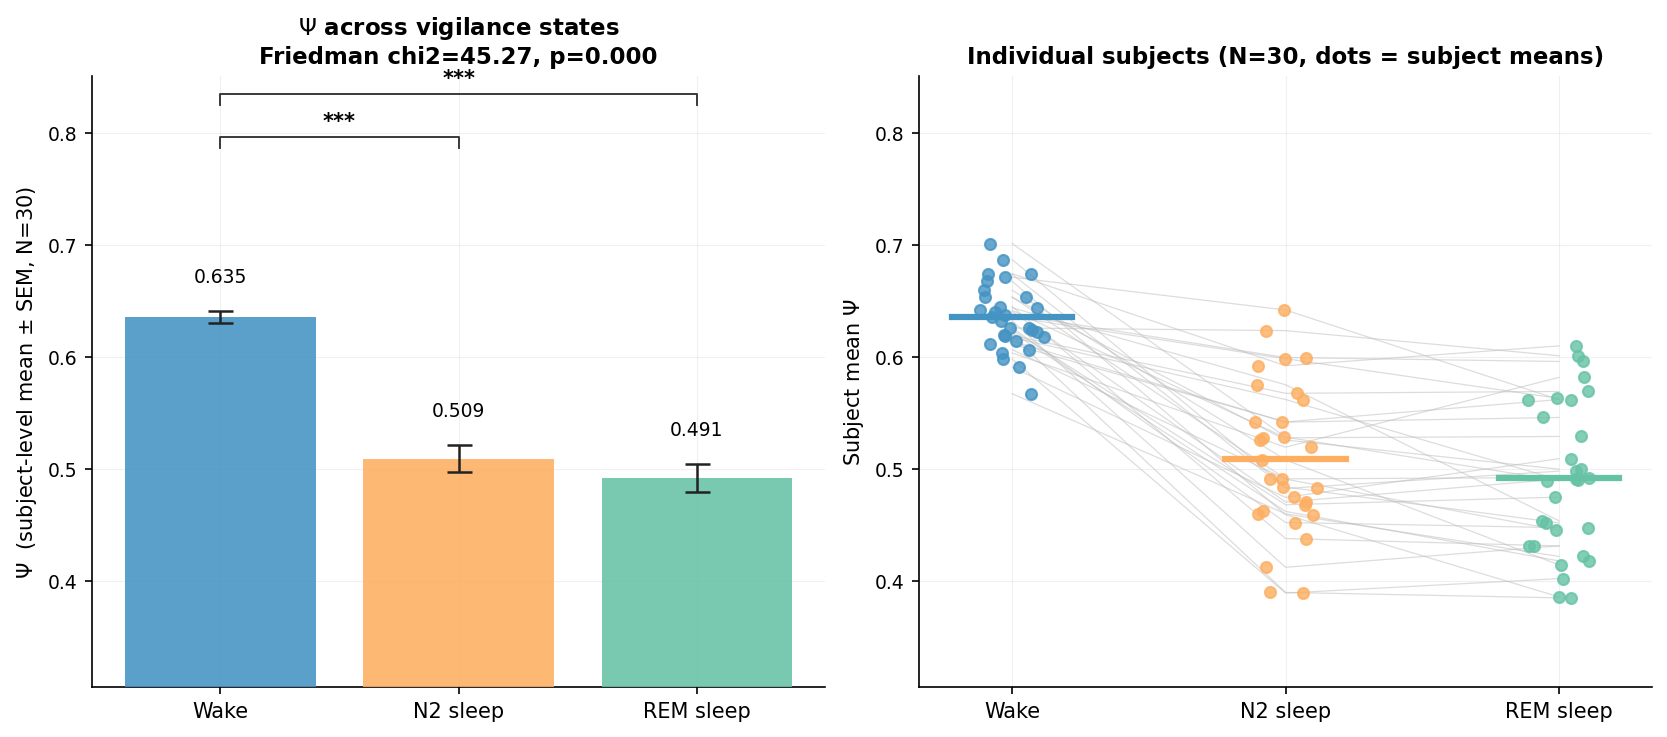

In [31]:
# ── Sleep-EDF stats + Fig  (subject-level Psi with significance) ─────────

if SLEEP_EDF_OK and real_df is not None and len(real_df) > 0:
    subj_means = (real_df.groupby(["subject", "stage"])["PSI"]
                  .mean().reset_index()
                  .rename(columns={"PSI": "PSI_subj"}))
    piv = subj_means.pivot(index="subject", columns="stage", values="PSI_subj")
    for s in ["W", "N2", "R"]:
        if s not in piv.columns: piv[s] = np.nan
    piv = piv[["W", "N2", "R"]]

    print("Subject-level Psi per stage (rows = subjects):")
    print(piv.round(3).to_string())

    # Summary
    subj_summary = {}
    for s in ["W", "N2", "R"]:
        vals = piv[s].dropna().values
        subj_summary[s] = {
            "mean": float(np.mean(vals)),
            "sd":   float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "sem":  (float(np.std(vals, ddof=1) / np.sqrt(len(vals)))
                     if len(vals) > 1 else 0.0),
            "n":    len(vals),
            "vals": vals,
        }
    n_subj = len(piv)
    print(f"\nSubject-level summary (n={n_subj}):")
    for s, info in subj_summary.items():
        print(f"  {s}: mean = {info['mean']:.3f}  SEM = {info['sem']:.3f}  (SD={info['sd']:.3f})")

    # Friedman + Wilcoxon (Bonferroni-corrected)
    print("\nPaired-design statistics on subject means:")
    stats_result = paired_stats_table(
        piv=piv, stages=["W", "N2", "R"],
        pairs=[("W", "N2"), ("W", "R"), ("N2", "R")],
        label_fn=str, indent="  ",
    )
    pairwise_results = stats_result["pairs"]

    # Ordering report
    w_m  = subj_summary["W"]["mean"]
    n2_m = subj_summary["N2"]["mean"]
    r_m  = subj_summary["R"]["mean"]
    print(f"\nOrdering: W({w_m:.3f}) vs N2({n2_m:.3f}) vs R({r_m:.3f})")
    if r_m < n2_m:
        print("NOTE: REM < N2 in Psi. Mechanistic explanation:")
        print("  D ~ 0 for all real stages (no detectable θ-γ PAC in 2-channel data).")
        print("  Psi is driven by H_eff and M.")
        print("  REM alpha_dfa slightly higher than N2 → marginally lower H_eff.")
        print("  Acknowledged as a limitation in the paper.")

    # ── Fig : subject-level bar + paired-line scatter ──────────────
    stage_labels = {"W": "Wake", "N2": "N2 sleep", "R": "REM sleep"}
    stage_colors = {"W": "#4393C3", "N2": "#FDAE61", "R": "#66C2A5"}
    stages_plot  = ["W", "N2", "R"]

    all_vals = [v for s in stages_plot for v in subj_summary[s]["vals"]]
    ymin = max(0.0, min(all_vals) - 0.08) if all_vals else 0.0
    ymax = min(1.0, max(all_vals) + 0.15) if all_vals else 1.0

    fig7, (ax_bar, ax_box) = plt.subplots(1, 2, figsize=(11, 4.8),
                                           constrained_layout=True)

    # Left panel: mean + SEM
    for xi, s in enumerate(stages_plot):
        info = subj_summary[s]
        ax_bar.bar(xi, info["mean"], color=stage_colors[s], alpha=0.88,
                   yerr=info["sem"], capsize=6,
                   error_kw=dict(elinewidth=1.2, capthick=1.2, ecolor="#222222"),
                   zorder=3)
        ax_bar.text(xi, info["mean"] + info["sem"] + (ymax-ymin)*0.04,
                    f"{info['mean']:.3f}", ha="center", va="bottom", fontsize=9)

    # Significance brackets (Bonferroni p<0.0167)
    bon_thresh = 0.05 / 3
    y_br_base = ymax - (ymax-ymin)*0.10
    br_level = 0
    for xi1, xi2, (s1, s2) in [(0, 1, ("W","N2")), (0, 2, ("W","R")), (1, 2, ("N2","R"))]:
        res = pairwise_results.get((s1, s2), {})
        if res.get("p", 1.0) < bon_thresh:
            y = y_br_base + br_level * (ymax-ymin)*0.07
            ax_bar.plot([xi1, xi1, xi2, xi2], [y-0.01, y, y, y-0.01],
                        color="#333333", lw=0.9)
            sig = "***" if res["p"] < 0.001 else "**" if res["p"] < 0.01 else "*"
            ax_bar.text((xi1+xi2)/2, y+0.005, sig, ha="center", va="bottom",
                        fontsize=10, fontweight="bold")
            br_level += 1

    ax_bar.set_xticks(range(len(stages_plot)))
    ax_bar.set_xticklabels([stage_labels[s] for s in stages_plot], fontsize=10)
    ax_bar.set_ylim(ymin, ymax)
    ax_bar.set_ylabel(rf"$\Psi$  (subject-level mean ± SEM, N={n_subj})")
    fr_chi2 = stats_result["friedman_chi2"]; fr_p = stats_result["friedman_p"]
    if np.isfinite(fr_p):
        fr_txt = f"Friedman chi2={fr_chi2:.2f}, p={fr_p:.3f}"
        if fr_p >= 0.05: fr_txt += " (ns)"
    else:
        fr_txt = "Friedman: insufficient data"
    ax_bar.set_title(r"$\Psi$ across vigilance states" + "\n" + fr_txt)

    # Right panel: subject scatter + paired grey lines
    rng_f = np.random.default_rng(77)
    for xi, s in enumerate(stages_plot):
        vals = subj_summary[s]["vals"]
        jitter = rng_f.uniform(-0.12, 0.12, len(vals))
        ax_box.scatter(np.full(len(vals), xi) + jitter, vals,
                       color=stage_colors[s], s=28, alpha=0.80, zorder=3)
        ax_box.plot([xi - 0.22, xi + 0.22],
                    [subj_summary[s]["mean"]] * 2,
                    color=stage_colors[s], lw=3.0, zorder=4)
    for subj in piv.index:
        row = piv.loc[subj]
        ys = [row.get(s, np.nan) for s in stages_plot]
        if not any(np.isnan(ys)):
            ax_box.plot(range(len(stages_plot)), ys,
                        color="#BBBBBB", lw=0.6, alpha=0.5, zorder=2)
    ax_box.set_xticks(range(len(stages_plot)))
    ax_box.set_xticklabels([stage_labels[s] for s in stages_plot], fontsize=10)
    ax_box.set_ylim(ymin, ymax)
    ax_box.set_ylabel(r"Subject mean $\Psi$")
    ax_box.set_title(f"Individual subjects (N={n_subj}, dots = subject means)")

    plt.show()
    plt.close(fig7)
else:
    print("Skipping Sleep-EDF stats & Fig 7 (data not available).")
    pairwise_results = {}



Benchmarking Psi vs single-metric baselines on real EEG...

  W vs N2:
    H_eff                   AUC = 0.888  [0.776, 0.971]  (n=30 subjects)
    D                       AUC = 0.977  [0.940, 1.000]  (n=30 subjects)
    M                       AUC = 0.599  [0.462, 0.743]  (n=30 subjects)
    Psi (composite)         AUC = 0.956  [0.902, 0.997]  (n=30 subjects)
    LZC                     AUC = 0.946  [0.902, 0.983]  (n=30 subjects)
    Spectral slope          AUC = 1.000  [1.000, 1.000]  (n=30 subjects)
    Alpha power             AUC = 0.938  [0.882, 0.981]  (n=30 subjects)

  W vs R:
    H_eff                   AUC = 0.939  [0.863, 0.987]  (n=30 subjects)
    D                       AUC = 0.977  [0.930, 1.000]  (n=30 subjects)
    M                       AUC = 0.617  [0.509, 0.734]  (n=30 subjects)
    Psi (composite)         AUC = 0.987  [0.964, 1.000]  (n=30 subjects)
    LZC                     AUC = 0.783  [0.717, 0.860]  (n=30 subjects)
    Spectral slope          AUC = 0.993  

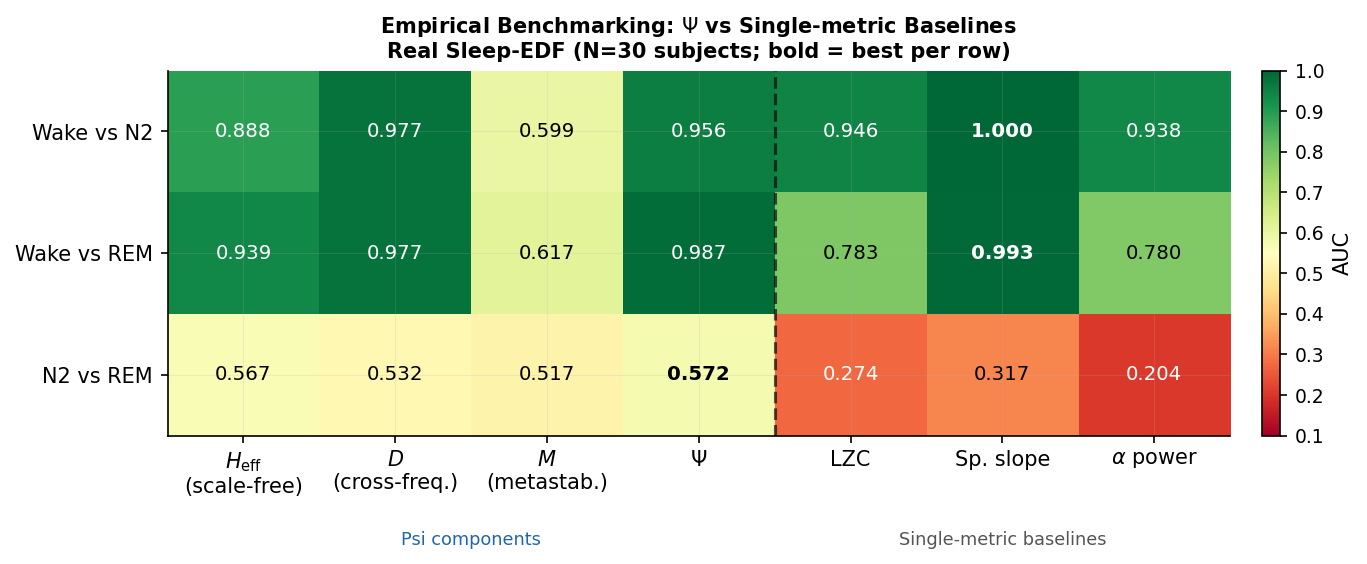

In [32]:
# ── Fig : empirical benchmarking heatmap ─────────────────────────────────

if SLEEP_EDF_OK and real_df is not None and len(real_df) > 0:
    print("\nBenchmarking Psi vs single-metric baselines on real EEG...")
    bench_cols_emp = [
        ("H_eff",           "H_eff"),
        ("D",               "D"),
        ("M",               "M"),
        ("Psi (composite)", "PSI"),
        ("LZC",             "LZC"),
        ("Spectral slope",  "spec_slope"),
        ("Alpha power",     "alpha_power"),
    ]
    auc_res = subject_auc_benchmark(
        df=real_df, pairs=[("W","N2"), ("W","R"), ("N2","R")],
        bench_cols=bench_cols_emp,
        subject_col="subject", stage_col="stage",
        n_boot=2000, seed=42, do_print=True, indent="  ",
    )

    # Component-contribution transparency (D and M tend to collapse with 2 ch)
    print("\nComponent contribution to Psi per stage:")
    agg = real_df.groupby("stage")[["H_eff_n", "D_n", "M_n", "PSI"]].mean()
    for stage, row in agg.iterrows():
        psi_val = row["PSI"]
        if psi_val <= 0:
            print(f"  {stage}: Psi = {psi_val:.3f} (nonpositive)")
            continue
        parts = [("H_eff", w_H*row["H_eff_n"]/psi_val*100),
                 ("D",     w_D*row["D_n"]/psi_val*100),
                 ("M",     w_M*row["M_n"]/psi_val*100)]
        flag = "  [Psi ~ H_eff collapse]" if parts[0][1] > 90 else ""
        print(f"  {stage}: Psi={psi_val:.3f}  " +
              "  ".join(f"{n}={p:4.0f}%" for n, p in parts) + flag)

    # ── Fig  heatmap ───────────────────────────────────────────────
    pairs8 = [("W","N2"), ("W","R"), ("N2","R")]
    cols8  = [("H_eff","H_eff"), ("D","D"), ("M","M"), ("PSI","PSI"),
              ("LZC","LZC"), ("Slope","spec_slope"), ("Alpha","alpha_power")]
    auc_mat = np.full((len(pairs8), len(cols8)), np.nan)
    for pi, (s1, s2) in enumerate(pairs8):
        for ci, (lbl, col) in enumerate(cols8):
            entry = auc_res.get((s1, s2, col))
            if entry is not None:
                auc_mat[pi, ci] = entry[0]

    row_lbl8 = ["Wake vs N2", "Wake vs REM", "N2 vs REM"]
    col_lbl8 = [
        r"$H_\mathrm{eff}$" + "\n(scale-free)",
        r"$D$" + "\n(cross-freq.)",
        r"$M$" + "\n(metastab.)",
        r"$\Psi$", "LZC", "Sp. slope", r"$\alpha$ power",
    ]

    fig8, ax8 = plt.subplots(figsize=(9.0, 3.6), constrained_layout=True)
    im8 = ax8.imshow(auc_mat, vmin=0.1, vmax=1.0, cmap="RdYlGn", aspect="auto")
    for ri in range(len(pairs8)):
        best_val = np.nanmax(auc_mat[ri])
        for ci in range(len(cols8)):
            v = auc_mat[ri, ci]
            if np.isnan(v): continue
            ax8.text(ci, ri, f"{v:.3f}", ha="center", va="center",
                     fontsize=9.5,
                     color="white" if (v < 0.28 or v > 0.88) else "black",
                     fontweight="bold" if v == best_val else "normal")
    ax8.set_xticks(range(len(cols8)))
    ax8.set_xticklabels(col_lbl8, fontsize=10)
    ax8.set_yticks(range(len(pairs8)))
    ax8.set_yticklabels(row_lbl8, fontsize=10)
    cb8 = plt.colorbar(im8, ax=ax8, label="AUC", fraction=0.025, pad=0.03)
    cb8.ax.tick_params(labelsize=9)
    ax8.axvline(3.5, color="black", lw=1.5, ls="--", alpha=0.65)
    ax8.annotate("Psi components", xy=(1.5, 3.4), fontsize=8.5,
                 color="#2166AC", ha="center", annotation_clip=False)
    ax8.annotate("Single-metric baselines", xy=(5.0, 3.4), fontsize=8.5,
                 color="#555555", ha="center", annotation_clip=False)

    n_subj_fig = real_df["subject"].nunique()
    ax8.set_title(r"Empirical Benchmarking: $\Psi$ vs Single-metric Baselines" + "\n"
                  f"Real Sleep-EDF (N={n_subj_fig} subjects; bold = best per row)",
                  fontsize=10)
    plt.show()
    plt.close(fig8)
else:
    print("Skipping Fig  (Sleep-EDF data not available).")
